# In this part, we merge the 5 datasets:
### 1. ev_stations
### 2. zillow_data
### 3. daily_42602_2023
### 4. daily_42602_2024
### 5. daily_42602_2025

In [ ]:
import pandas as pd


# 1. LOAD EV DATASET
ev_df = pd.read_csv('ev_stations.csv', low_memory=False)

# 2. LOAD COUNTY-LEVEL ZILLOW DATASET
zillow_df = pd.read_csv('zillow_data.csv')


# 3. LOAD BRIDGE DATASET FOR EV ONLY
census_url = "https://www2.census.gov/geo/docs/maps-data/data/rel/zcta_county_rel_10.txt"
bridge_df = pd.read_csv(census_url)

bridge_df['fips'] = (
    bridge_df['STATE'].astype(str).str.zfill(2) +
    bridge_df['COUNTY'].astype(str).str.zfill(3)
)

bridge_df = bridge_df[['ZCTA5', 'fips']]
bridge_df.columns = ['zip', 'fips']
bridge_df['zip'] = bridge_df['zip'].astype(str).str.zfill(5)

# Keep one FIPS per ZIP
bridge_main = (
    bridge_df
    .sort_values(['zip', 'fips'])
    .drop_duplicates(subset='zip', keep='first')
    .copy()
)

print("--- SUCCESS ---")
print(f"Bridge Data Rows: {len(bridge_main)}")
print(f"Sample Bridge Data:\n{bridge_main.head(3)}")


# PREPARE COMMON EV DATA
ev_df['ZIP'] = ev_df['ZIP'].astype(str).str.zfill(5)
ev_df['Open Date'] = pd.to_datetime(ev_df['Open Date'], format='%m/%d/%Y', errors='coerce')
ev_df['Year'] = ev_df['Open Date'].dt.year


# COMMON ZILLOW ID COLUMNS
id_cols = [
    'RegionID', 'SizeRank', 'RegionName', 'RegionType',
    'StateName', 'State', 'Metro', 'StateCodeFIPS', 'MunicipalCodeFIPS'
]


def prepare_ev(year):
    ev_year = ev_df[ev_df['Year'] == year].copy()

    ev_with_fips = pd.merge(
        ev_year,
        bridge_main[['zip', 'fips']],
        left_on='ZIP',
        right_on='zip',
        how='left'
    ).drop(columns=['zip'])

    return ev_with_fips


def prepare_zillow(year):
    zillow_cols = [col for col in zillow_df.columns if str(year) in str(col)]
    zillow_year = zillow_df[id_cols + zillow_cols].copy()

    zillow_year['StateCodeFIPS'] = zillow_year['StateCodeFIPS'].astype(str).str.zfill(2)
    zillow_year['MunicipalCodeFIPS'] = zillow_year['MunicipalCodeFIPS'].astype(str).str.zfill(3)
    zillow_year['fips'] = zillow_year['StateCodeFIPS'] + zillow_year['MunicipalCodeFIPS']

    zillow_long = pd.melt(
        zillow_year,
        id_vars=id_cols + ['fips'],
        var_name='Date',
        value_name='Price'
    )

    zillow_long['Date'] = pd.to_datetime(zillow_long['Date'], errors='coerce')
    zillow_long['Year'] = zillow_long['Date'].dt.year
    zillow_long['Price'] = pd.to_numeric(zillow_long['Price'], errors='coerce')

    zillow_county = (
        zillow_long
        .dropna(subset=['fips', 'Year', 'Price'])
        .groupby(['fips', 'Year'], as_index=False)
        .agg({
            'Price': 'mean',
            'RegionName': 'first',
            'RegionType': 'first',
            'StateName': 'first',
            'State': 'first',
            'Metro': 'first',
            'StateCodeFIPS': 'first',
            'MunicipalCodeFIPS': 'first',
            'RegionID': 'first',
            'SizeRank': 'first'
        })
        .rename(columns={'Price': 'Avg_Price'})
    )

    return zillow_county


def prepare_epa(year, file_name):
    epa_df = pd.read_csv(file_name, dtype=str, low_memory=False)

    epa_df['State Code'] = epa_df['State Code'].astype(str).str.zfill(2)
    epa_df['County Code'] = epa_df['County Code'].astype(str).str.zfill(3)
    epa_df['fips'] = epa_df['State Code'] + epa_df['County Code']

    epa_df['Date Local'] = pd.to_datetime(epa_df['Date Local'], errors='coerce')
    epa_df['Year'] = epa_df['Date Local'].dt.year
    epa_df['Arithmetic Mean'] = pd.to_numeric(epa_df['Arithmetic Mean'], errors='coerce')

    epa_year = epa_df[epa_df['Year'] == year].copy()

    # Daily data -> average all daily county values over the year
    epa_county = (
        epa_year
        .dropna(subset=['fips', 'Year', 'Arithmetic Mean'])
        .groupby(['fips', 'Year'], as_index=False)
        .agg({
            'Arithmetic Mean': 'mean',
            'State Code': 'first',
            'County Code': 'first',
            'State Name': 'first',
            'County Name': 'first',
            'City Name': 'first',
            'Parameter Name': 'first',
            'Units of Measure': 'first'
        })
        .rename(columns={'Arithmetic Mean': 'Avg_NO2'})
    )

    return epa_county


def build_dataset(year, epa_file, output_name):
    ev = prepare_ev(year)
    zillow = prepare_zillow(year)
    epa = prepare_epa(year, epa_file)

    for df in [ev, zillow, epa]:
        df['fips'] = df['fips'].astype(str).str.zfill(5)
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

    ev = ev.dropna(subset=['fips', 'Year'])
    zillow = zillow.dropna(subset=['fips', 'Year'])
    epa = epa.dropna(subset=['fips', 'Year'])

    merged_ev_zillow = pd.merge(
        ev,
        zillow,
        on=['fips', 'Year'],
        how='inner',
        suffixes=('_ev', '_zillow')
    )

    final = pd.merge(
        merged_ev_zillow,
        epa,
        on=['fips', 'Year'],
        how='inner'
    )

    print(f"EV {year}:", ev.shape)
    print(f"Zillow county {year}:", zillow.shape)
    print(f"EPA county {year}:", epa.shape)
    print(f"Final {year}:", final.shape)

    num_counties = final['fips'].nunique()
    print(f"Distinct counties in final {year} dataset:", num_counties)

    print(final.head())

    final.to_csv(output_name, index=False)

    return final


# BUILD ALL 3 YEARS
final_full_2023 = build_dataset(
    2023,
    'daily_42602_2023.csv',
    'final_full_2023.csv',
)

final_full_2024 = build_dataset(
    2024,
    'daily_42602_2024.csv',
    'final_full_2024.csv',
)

final_full_2025 = build_dataset(
    2025,
    'daily_42602_2025.csv',
    'final_full_2025.csv',
)

FileNotFoundError: [Errno 2] No such file or directory: 'ev_stations.csv'

In [ ]:
import pandas as pd

# Load the 3 final datasets
final_2023 = pd.read_csv("final_full_2023.csv", low_memory=False)
final_2024 = pd.read_csv("final_full_2024.csv", low_memory=False)
final_2025 = pd.read_csv("final_full_2025.csv", low_memory=False)

# Combine all rows
final_all_years = pd.concat(
    [final_2023, final_2024, final_2025],
    axis=0,
    ignore_index=True,
    sort=False
)

# Optional: keep only one copy if the exact same EV station row appears more than once
final_all_years = final_all_years.drop_duplicates()

# Save
final_all_years.to_csv("final_full_2023_2024_2025.csv", index=False)

# Checks
print("2023 shape:", final_2023.shape)
print("2024 shape:", final_2024.shape)
print("2025 shape:", final_2025.shape)
print("Combined shape:", final_all_years.shape)
print("Distinct counties:", final_all_years['fips'].nunique())
print(final_all_years.head())

In [ ]:
# Count distinct counties (FIPS)
print("Distinct counties in 2023:", final_2023['fips'].nunique())
print("Distinct counties in 2024:", final_2024['fips'].nunique())
print("Distinct counties in 2025:", final_2025['fips'].nunique())

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1) LOAD DATA
# =========================
ev_df = pd.read_csv("ev_stations.csv", low_memory=False)
zillow_df = pd.read_csv("zillow_data.csv", low_memory=False)

epa_2023 = pd.read_csv("daily_42602_2023.csv", dtype=str, low_memory=False)
epa_2024 = pd.read_csv("daily_42602_2024.csv", dtype=str, low_memory=False)
epa_2025 = pd.read_csv("daily_42602_2025.csv", dtype=str, low_memory=False)

# =========================
# 2) ZIP -> FIPS BRIDGE
# =========================
census_url = "https://www2.census.gov/geo/docs/maps-data/data/rel/zcta_county_rel_10.txt"
bridge_df = pd.read_csv(census_url)

bridge_df["fips"] = (
    bridge_df["STATE"].astype(str).str.zfill(2) +
    bridge_df["COUNTY"].astype(str).str.zfill(3)
)

bridge_df = bridge_df[["ZCTA5", "fips"]].copy()
bridge_df.columns = ["zip", "fips"]
bridge_df["zip"] = bridge_df["zip"].astype(str).str.zfill(5)

bridge_main = (
    bridge_df
    .sort_values(["zip", "fips"])
    .drop_duplicates(subset="zip", keep="first")
    .copy()
)

# =========================
# 3) EV -> COUNTY-YEAR
# =========================
ev_df["ZIP"] = ev_df["ZIP"].astype(str).str.zfill(5)
ev_df["Open Date"] = pd.to_datetime(ev_df["Open Date"], format="%m/%d/%Y", errors="coerce")
ev_df["Year"] = ev_df["Open Date"].dt.year

# keep only 2023-2025
ev_df = ev_df[ev_df["Year"].isin([2023, 2024, 2025])].copy()

ev_df = pd.merge(
    ev_df,
    bridge_main[["zip", "fips"]],
    left_on="ZIP",
    right_on="zip",
    how="left"
).drop(columns=["zip"])

# IMPORTANT: remove rows where FIPS is missing before converting to string
ev_df = ev_df.dropna(subset=["fips"]).copy()
ev_df["fips"] = ev_df["fips"].astype(str).str.zfill(5)

# extra safety: remove fake fips values
ev_df = ev_df[ev_df["fips"].str.match(r"^\d{5}$", na=False)].copy()

ev_county_year = (
    ev_df
    .dropna(subset=["fips", "Year"])
    .groupby(["fips", "Year"], as_index=False)
    .agg(
        EV_Count=("fips", "size"),
        EV_New_Stations=("fips", "size")
    )
    .sort_values(["fips", "Year"])
)

ev_county_year["EV_Growth_Rate"] = (
    ev_county_year.groupby("fips")["EV_Count"].pct_change() * 100
)
ev_county_year["EV_Growth_Rate"] = ev_county_year["EV_Growth_Rate"].replace([np.inf, -np.inf], np.nan)

# =========================
# 4) ZILLOW -> COUNTY-YEAR
# =========================
id_cols = [
    "RegionID", "SizeRank", "RegionName", "RegionType",
    "StateName", "State", "Metro", "StateCodeFIPS", "MunicipalCodeFIPS"
]

zillow_cols = [c for c in zillow_df.columns if any(str(y) in str(c) for y in [2023, 2024, 2025])]
zillow_sub = zillow_df[id_cols + zillow_cols].copy()

zillow_sub["StateCodeFIPS"] = zillow_sub["StateCodeFIPS"].astype(str).str.zfill(2)
zillow_sub["MunicipalCodeFIPS"] = zillow_sub["MunicipalCodeFIPS"].astype(str).str.zfill(3)
zillow_sub["fips"] = zillow_sub["StateCodeFIPS"] + zillow_sub["MunicipalCodeFIPS"]

zillow_long = pd.melt(
    zillow_sub,
    id_vars=id_cols + ["fips"],
    var_name="Date",
    value_name="Price"
)

zillow_long["Date"] = pd.to_datetime(zillow_long["Date"], errors="coerce")
zillow_long["Year"] = zillow_long["Date"].dt.year
zillow_long["Price"] = pd.to_numeric(zillow_long["Price"], errors="coerce")
zillow_long["fips"] = zillow_long["fips"].astype(str).str.zfill(5)

zillow_long = zillow_long[zillow_long["Year"].isin([2023, 2024, 2025])].copy()
zillow_long = zillow_long.dropna(subset=["fips", "Year", "Price"]).copy()
zillow_long = zillow_long[zillow_long["fips"].str.match(r"^\d{5}$", na=False)].copy()

zillow_county_year = (
    zillow_long
    .groupby(["fips", "Year"], as_index=False)
    .agg(
        RegionName=("RegionName", "first"),
        StateName=("StateName", "first"),
        StateCodeFIPS=("StateCodeFIPS", "first"),
        MunicipalCodeFIPS=("MunicipalCodeFIPS", "first"),
        Price_Q25=("Price", lambda s: s.quantile(0.25)),
        Price_Q50=("Price", lambda s: s.quantile(0.50)),
        Price_Q75=("Price", lambda s: s.quantile(0.75))
    )
    .sort_values(["fips", "Year"])
)

zillow_county_year["Price_Growth_Pct"] = (
    zillow_county_year.groupby("fips")["Price_Q50"].pct_change() * 100
)
zillow_county_year["Price_Growth_Pct"] = zillow_county_year["Price_Growth_Pct"].replace([np.inf, -np.inf], np.nan)

# =========================
# 5) EPA -> COUNTY-YEAR
# =========================
def prepare_epa(df):
    df = df.copy()
    df["State Code"] = df["State Code"].astype(str).str.zfill(2)
    df["County Code"] = df["County Code"].astype(str).str.zfill(3)
    df["fips"] = df["State Code"] + df["County Code"]
    df["Date Local"] = pd.to_datetime(df["Date Local"], errors="coerce")
    df["Year"] = df["Date Local"].dt.year
    df["Arithmetic Mean"] = pd.to_numeric(df["Arithmetic Mean"], errors="coerce")
    return df

epa_all = pd.concat(
    [prepare_epa(epa_2023), prepare_epa(epa_2024), prepare_epa(epa_2025)],
    ignore_index=True
)

epa_all = epa_all[epa_all["Year"].isin([2023, 2024, 2025])].copy()
epa_all = epa_all.dropna(subset=["fips", "Year", "Arithmetic Mean"]).copy()
epa_all["fips"] = epa_all["fips"].astype(str).str.zfill(5)
epa_all = epa_all[epa_all["fips"].str.match(r"^\d{5}$", na=False)].copy()

epa_county_year = (
    epa_all
    .groupby(["fips", "Year"], as_index=False)
    .agg(
        EPA_State_Code=("State Code", "first"),
        EPA_County_Code=("County Code", "first"),
        NO2_Q25=("Arithmetic Mean", lambda s: s.quantile(0.25)),
        NO2_Q50=("Arithmetic Mean", lambda s: s.quantile(0.50)),
        NO2_Q75=("Arithmetic Mean", lambda s: s.quantile(0.75)),
        NO2_Mean=("Arithmetic Mean", "mean"),
        NO2_Peak=("Arithmetic Mean", "max")
    )
)

# =========================
# 6) KEEP ONLY COUNTY-YEAR IN ALL 3 DATASETS
# =========================
county_year_panel = pd.merge(
    ev_county_year,
    zillow_county_year,
    on=["fips", "Year"],
    how="inner"
)

county_year_panel = pd.merge(
    county_year_panel,
    epa_county_year,
    on=["fips", "Year"],
    how="inner"
)

# =========================
# 7) FINAL FILTER: rows must have actual data from all 3
# =========================
required_cols = [
    "EV_Count",
    "Price_Q25", "Price_Q50", "Price_Q75",
    "NO2_Q25", "NO2_Q50", "NO2_Q75", "NO2_Mean", "NO2_Peak"
]

county_year_panel = county_year_panel.dropna(subset=required_cols).copy()

# =========================
# 8) FINAL COLUMN ORDER
# =========================
final_cols = [
    "fips",
    "Year",
    "EV_Count",
    "EV_New_Stations",
    "EV_Growth_Rate",
    "RegionName",
    "StateName",
    "StateCodeFIPS",
    "MunicipalCodeFIPS",
    "Price_Q25",
    "Price_Q50",
    "Price_Q75",
    "Price_Growth_Pct",
    "EPA_State_Code",
    "EPA_County_Code",
    "NO2_Q25",
    "NO2_Q50",
    "NO2_Q75",
    "NO2_Mean",
    "NO2_Peak",
]

county_year_panel = county_year_panel[[c for c in final_cols if c in county_year_panel.columns]]
county_year_panel = county_year_panel.sort_values(["fips", "Year"]).reset_index(drop=True)

# =========================
# 9) SAVE + CHECK
# =========================
county_year_panel.to_csv("county_year_panel_complete_only.csv", index=False)

print("Shape:", county_year_panel.shape)
print("Distinct counties:", county_year_panel["fips"].nunique())
print("Years:")
print(county_year_panel["Year"].value_counts().sort_index())
print(county_year_panel.head())

# In the next part, we fill in the population of each county in the dataset. We create a new feature: population

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Load your main dataset
# =========================
df = pd.read_csv("county_year_panel_complete_only.csv")

df["fips"] = df["fips"].astype(str).str.zfill(5)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df["County_clean"] = (
    df["RegionName"]
    .astype(str)
    .str.replace(" County", "", regex=False)
    .str.strip()
    .str.lower()
)


# =========================
# 2. Load population CSV correctly
# =========================
# The real table starts around row 5 in your screenshot
pop = pd.read_csv("population.csv", skiprows=4)

# Rename columns manually
pop = pop.rename(columns={
    pop.columns[0]: "Geographic Area",
    pop.columns[1]: "Base_2020",
    pop.columns[2]: "2020",
    pop.columns[3]: "2021",
    pop.columns[4]: "2022",
    pop.columns[5]: "2023",
    pop.columns[6]: "2024",
    pop.columns[7]: "2025"
})

# Keep only real county rows
pop = pop[pop["Geographic Area"].astype(str).str.startswith(".")].copy()

# Remove leading dot
pop["Geographic Area"] = pop["Geographic Area"].astype(str).str.replace(".", "", n=1, regex=False)

# Split county and state
pop[["County", "State_full"]] = pop["Geographic Area"].str.split(",", n=1, expand=True)

pop["County_clean"] = (
    pop["County"]
    .astype(str)
    .str.replace(" County", "", regex=False)
    .str.strip()
    .str.lower()
)

pop["State_full"] = pop["State_full"].astype(str).str.strip()


# =========================
# 3. Convert state full name to abbreviation
# =========================
state_map = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District of Columbia": "DC"
}

pop["StateName"] = pop["State_full"].map(state_map)


# =========================
# 4. Reshape population to long format
# =========================
pop_long = pop.melt(
    id_vars=["County_clean", "StateName"],
    value_vars=["2023", "2024", "2025"],
    var_name="Year",
    value_name="Population"
)

pop_long["Year"] = pd.to_numeric(pop_long["Year"], errors="coerce")

pop_long["Population"] = (
    pop_long["Population"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

pop_long["Population"] = pd.to_numeric(pop_long["Population"], errors="coerce")


# =========================
# 5. Merge population into your dataset
# =========================
df = df.merge(
    pop_long,
    on=["County_clean", "StateName", "Year"],
    how="left"
)


# =========================
# 6. Add density features
# =========================
df["EV_per_100k"] = (df["EV_Count"] / df["Population"]) * 100000
df["log_EV_Count"] = np.log1p(df["EV_Count"])


# =========================
# 7. Clean + save
# =========================
df = df.drop(columns=["County_clean"], errors="ignore")

df.to_csv("county_year_with_population_density.csv", index=False)


# =========================
# 8. Checks
# =========================
print("Shape:", df.shape)
print("Missing population:", df["Population"].isna().sum())

print(df[[
    "fips", "Year", "RegionName", "StateName",
    "EV_Count", "Population", "EV_per_100k"
]].head(20))

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("county_year_with_population_density.csv")

# Ensure EV_Count numeric
df["EV_Count"] = pd.to_numeric(df["EV_Count"], errors="coerce")

# FIX: clean population FIRST, then convert
df["Population"] = (
    df["Population"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Population"] = pd.to_numeric(df["Population"], errors="coerce")

# Ensure EV_per_100k numeric
df["EV_per_100k"] = pd.to_numeric(df["EV_per_100k"], errors="coerce")

# Fill missing values
mask = df["EV_per_100k"].isna() & df["Population"].notna() & (df["Population"] > 0)

df.loc[mask, "EV_per_100k"] = (
    df.loc[mask, "EV_Count"] / df.loc[mask, "Population"]
) * 100000

# Clean infinities
df["EV_per_100k"] = df["EV_per_100k"].replace([np.inf, -np.inf], np.nan)

# Save
df.to_csv("county_year_with_density.csv", index=False)

# Debug
print("Missing Population:", df["Population"].isna().sum())
print("Missing EV_per_100k:", df["EV_per_100k"].isna().sum())

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Load your main dataset
# =========================
df = pd.read_csv("county_year_with_density (3).csv")

df["fips"] = df["fips"].astype(str).str.zfill(5)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# =========================
# 2. Load population CSV
# =========================
pop_df = pd.read_csv("population.csv", skiprows=4, header=None)

pop_df = pop_df.iloc[:, :8]
pop_df.columns = [
    "RegionName", "Base", "2020", "2021", "2022", "2023", "2024", "2025"
]

# Clean region name
pop_df["RegionName"] = (
    pop_df["RegionName"]
    .astype(str)
    .str.replace(".", "", n=1, regex=False)
    .str.split(",")
    .str[0]
    .str.strip()
)

# Clean numeric population columns
for col in ["2023", "2024", "2025"]:
    pop_df[col] = (
        pop_df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    pop_df[col] = pd.to_numeric(pop_df[col], errors="coerce")

# =========================
# 3. CT Planning Region -> old county FIPS mapping
# =========================
ct_mapping = {
    "Western Connecticut Planning Region": "09001",          # Fairfield approximation
    "Greater Bridgeport Planning Region": "09001",           # Fairfield approximation

    "Capitol Planning Region": "09003",                      # Hartford approximation

    "Northwest Hills Planning Region": "09005",              # Litchfield approximation

    "Lower Connecticut River Valley Planning Region": "09007", # Middlesex approximation

    "Naugatuck Valley Planning Region": "09009",             # New Haven approximation
    "South Central Connecticut Planning Region": "09009",    # New Haven approximation

    "Southeastern Connecticut Planning Region": "09011",     # New London approximation

    "Northeastern Connecticut Planning Region": "09015",     # Windham approximation
}

pop_df["fips"] = pop_df["RegionName"].map(ct_mapping)

# Keep only mapped CT planning regions
ct_pop = pop_df.dropna(subset=["fips"]).copy()

# Sum population for regions mapped to same old county FIPS
ct_fixed_pop = (
    ct_pop
    .groupby("fips", as_index=False)[["2023", "2024", "2025"]]
    .sum()
)

# Convert to long format
ct_fixed_pop_long = ct_fixed_pop.melt(
    id_vars="fips",
    value_vars=["2023", "2024", "2025"],
    var_name="Year",
    value_name="CT_Population"
)

ct_fixed_pop_long["Year"] = pd.to_numeric(ct_fixed_pop_long["Year"], errors="coerce")
ct_fixed_pop_long["fips"] = ct_fixed_pop_long["fips"].astype(str).str.zfill(5)

print("--- Fixed CT Population ---")
print(ct_fixed_pop_long.head(20))

# =========================
# 4. Merge CT population into main dataset
# =========================
df = df.merge(
    ct_fixed_pop_long,
    on=["fips", "Year"],
    how="left"
)

# Clean existing Population
df["Population"] = (
    df["Population"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Population"] = pd.to_numeric(df["Population"], errors="coerce")

# Fill missing Population only for CT rows where CT_Population exists
mask = df["Population"].isna() & df["CT_Population"].notna()

df.loc[mask, "Population"] = df.loc[mask, "CT_Population"]

# =========================
# 5. Recompute EV_per_100k
# =========================
df["EV_Count"] = pd.to_numeric(df["EV_Count"], errors="coerce")

df["EV_per_100k"] = (df["EV_Count"] / df["Population"]) * 100000
df["EV_per_100k"] = df["EV_per_100k"].replace([np.inf, -np.inf], np.nan)

# Optional log feature
df["log_EV_Count"] = np.log1p(df["EV_Count"])

# Drop helper column
df = df.drop(columns=["CT_Population"], errors="ignore")

# Save
df.to_csv("county_year_with_density_fixed.csv", index=False)

# =========================
# 6. Checks
# =========================
print("Missing Population:", df["Population"].isna().sum())
print("Missing EV_per_100k:", df["EV_per_100k"].isna().sum())

print(
    df[df["StateName"] == "CT"][
        ["fips", "Year", "RegionName", "StateName", "EV_Count", "Population", "EV_per_100k"]
    ]
)

## In this part, we add 2 new features: county area and population density

In [ ]:
import pandas as pd

# ============================
# Read project dataset
# ============================
df = pd.read_csv("county_year_with_density_fixed.csv")

# ============================
# Read Gazetteer files
# ============================
import pandas as pd

import pandas as pd

gaz2023 = pd.read_csv(
    "2023_Gaz_counties_national.txt",
    sep="\t",
    dtype={"GEOID": str}
)

gaz2024 = pd.read_csv(
    "2024_Gaz_counties_national.txt",
    sep="\t",
    dtype={"GEOID": str}
)

gaz2025 = pd.read_csv(
    "2025_Gaz_counties_national.txt",
    sep="|",
    dtype={"GEOID": str}
)

print("2023 columns:", gaz2023.columns.tolist())
print("2024 columns:", gaz2024.columns.tolist())
print("2025 columns:", gaz2025.columns.tolist())


# Keep only required columns
gaz2023 = gaz2023[["GEOID", "ALAND_SQMI"]].copy()
gaz2024 = gaz2024[["GEOID", "ALAND_SQMI"]].copy()
gaz2025 = gaz2025[["GEOID", "ALAND_SQMI"]].copy()

# Rename columns
for gaz in [gaz2023, gaz2024, gaz2025]:
    gaz.rename(
        columns={
            "GEOID": "fips",
            "ALAND_SQMI": "Land_Area_sqmi"
        },
        inplace=True
    )

# Add year
gaz2023["Year"] = 2023
gaz2024["Year"] = 2024
gaz2025["Year"] = 2025

# Combine the three years
gaz_all = pd.concat(
    [gaz2023, gaz2024, gaz2025],
    ignore_index=True
)

# Standardise merge columns
df["fips"] = df["fips"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)
gaz_all["fips"] = gaz_all["fips"].astype(str).str.zfill(5)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
gaz_all["Year"] = gaz_all["Year"].astype("Int64")

# Merge by county and year
df = df.merge(
    gaz_all,
    on=["fips", "Year"],
    how="left",
    validate="many_to_one"
)

# Ensure numeric values
df["Population"] = pd.to_numeric(df["Population"], errors="coerce")
df["Land_Area_sqmi"] = pd.to_numeric(df["Land_Area_sqmi"], errors="coerce")

# Create population density: people per square mile
df["Population_Density"] = (
    df["Population"] / df["Land_Area_sqmi"]
)

# Check the result
print(
    df[
        [
            "fips",
            "Year",
            "Population",
            "Land_Area_sqmi",
            "Population_Density"
        ]
    ].head()
)

print("\nMissing land area:", df["Land_Area_sqmi"].isna().sum())
print("Missing density:", df["Population_Density"].isna().sum())

# Save
df.to_csv(
    "dataset_with_population_density.csv",
    index=False
)

2023 columns: ['USPS', 'GEOID', 'ANSICODE', 'NAME', 'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT', 'INTPTLONG                                                                                                               ']
2024 columns: ['USPS', 'GEOID', 'ANSICODE', 'NAME', 'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT', 'INTPTLONG                                                                                                               ']
2025 columns: ['USPS', 'GEOID', 'GEOIDFQ', 'ANSICODE', 'NAME', 'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT', 'INTPTLONG']
    fips  Year  Population  Land_Area_sqmi  Population_Density
0  01073  2023    664419.0        1111.540          597.746370
1  01073  2024    666585.0        1111.556          599.686386
2  01073  2025    665742.0        1111.567          598.922062
3  04013  2023   4601077.0        9202.016          500.007498
4  04013  2024   4654147.0        9202.016          505.774713

Missing land 

# Now we will add a new feature: vmt (Vehicle miles traveled)

In [ ]:

import os
import glob
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')


df = pd.read_csv("final_dataset__.csv")

# ================================================================
# COUNTY-LEVEL VMT FEATURE ENGINEERING
#
# This cell:
# 1. Reads the large 2024 HPMS CSV in chunks.
# 2. Calculates county-level 2024 DVMT from roadway sections.
# 3. Reads the 2024 and 2025 FHWA Traffic Volume Trends files.
# 4. Calculates state growth factors for 2023→2024 and 2024→2025.
# 5. Estimates county DVMT and annual VMT for 2023 and 2025.
# 6. Merges DVMT and VMT into the main dataframe df by fips and Year.

# ================================================================
# 1. DEFINE FILE PATHS AND SETTINGS
# ================================================================

# Path to the large 2024 HPMS CSV file.
HPMS_PATH = "/content/drive/MyDrive/HPMS_Spatial_All_Sections_2024.csv"

# Folder containing:
# 24jantvt.xlsx ... 24dectvt.xlsx
# 25jantvt.xlsx ... 25dectvt.xlsx
TVT_FOLDER = "/content/drive/MyDrive/Traffic_Volume_Trends"

# Number of HPMS rows to process at once.
# Reduce this value if Colab runs out of memory.
CHUNK_SIZE = 500_000

# Name of the year column in the main merged dataframe.
YEAR_COLUMN = "Year"

# Name of the county FIPS column in the main merged dataframe.
FIPS_COLUMN = "fips"


# ================================================================
# 2. STATE NAME TO STATE FIPS MAPPING
#
# The TVT workbooks identify states by name, while HPMS uses state
# FIPS codes. This dictionary allows us to connect the two sources.
# ================================================================

STATE_NAME_TO_FIPS = {
    "Alabama": "01",
    "Alaska": "02",
    "Arizona": "04",
    "Arkansas": "05",
    "California": "06",
    "Colorado": "08",
    "Connecticut": "09",
    "Delaware": "10",
    "District of Columbia": "11",
    "Florida": "12",
    "Georgia": "13",
    "Hawaii": "15",
    "Idaho": "16",
    "Illinois": "17",
    "Indiana": "18",
    "Iowa": "19",
    "Kansas": "20",
    "Kentucky": "21",
    "Louisiana": "22",
    "Maine": "23",
    "Maryland": "24",
    "Massachusetts": "25",
    "Michigan": "26",
    "Minnesota": "27",
    "Mississippi": "28",
    "Missouri": "29",
    "Montana": "30",
    "Nebraska": "31",
    "Nevada": "32",
    "New Hampshire": "33",
    "New Jersey": "34",
    "New Mexico": "35",
    "New York": "36",
    "North Carolina": "37",
    "North Dakota": "38",
    "Ohio": "39",
    "Oklahoma": "40",
    "Oregon": "41",
    "Pennsylvania": "42",
    "Rhode Island": "44",
    "South Carolina": "45",
    "South Dakota": "46",
    "Tennessee": "47",
    "Texas": "48",
    "Utah": "49",
    "Vermont": "50",
    "Virginia": "51",
    "Washington": "53",
    "West Virginia": "54",
    "Wisconsin": "55",
    "Wyoming": "56"
}


# ================================================================
# 3. CHECK WHICH COLUMNS EXIST IN THE HPMS FILE
#
# FACILITY_TYPE is used when available to exclude non-inventory
# direction records, which may duplicate traffic in the inventory
# direction.
# ================================================================

if not os.path.exists(HPMS_PATH):
    raise FileNotFoundError(
        f"HPMS file was not found:\n{HPMS_PATH}\n"
        "Update HPMS_PATH before running the cell."
    )

hpms_columns = pd.read_csv(
    HPMS_PATH,
    nrows=0,
    low_memory=False
).columns.tolist()


required_hpms_columns = [
    "StateID",
    "YEAR_RECORD",
    "ROUTE_ID",
    "COUNTY_ID",
    "AADT",
    "SectionLength"
]

missing_hpms_columns = [
    column for column in required_hpms_columns
    if column not in hpms_columns
]

if missing_hpms_columns:
    raise ValueError(
        "The following required HPMS columns are missing: "
        f"{missing_hpms_columns}"
    )

columns_to_read = required_hpms_columns.copy()

if "FACILITY_TYPE" in hpms_columns:
    columns_to_read.append("FACILITY_TYPE")
    print("FACILITY_TYPE was found. Records with FACILITY_TYPE = 6 will be excluded.")
else:
    print(
        "Warning: FACILITY_TYPE was not found. "
        "Non-inventory direction records cannot be removed."
    )


# ================================================================
# 4. READ HPMS IN CHUNKS AND CALCULATE 2024 COUNTY DVMT
#
# For every roadway section:
#
# Segment length = END_POINT - BEGIN_POINT
#
# Segment DVMT = AADT × segment length
#
# AADT is the average number of vehicles travelling on the section
# per day. Multiplying it by section length gives daily
# vehicle-miles travelled on that section.
# ================================================================

# Reset results before rerunning the HPMS processing


county_chunk_results = []
rows_read = 0
rows_retained = 0

for chunk_number, chunk in enumerate(
    pd.read_csv(
        HPMS_PATH,
        usecols=columns_to_read,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):
    rows_read += len(chunk)

    # Convert ordinary numeric columns.
    # IMPORTANT: Do not include AADT here because it contains commas.
    for column in [
        "StateID",
        "YEAR_RECORD",
        "COUNTY_ID",
        "SectionLength"
    ]:
        chunk[column] = pd.to_numeric(
            chunk[column],
            errors="coerce"
        )

    # Clean AADT directly from its original text representation.
    # Example: "5,628" becomes 5628.
    chunk["AADT"] = pd.to_numeric(
        chunk["AADT"]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

    # Convert FACILITY_TYPE separately if available.
    if "FACILITY_TYPE" in chunk.columns:
        chunk["FACILITY_TYPE"] = pd.to_numeric(
            chunk["FACILITY_TYPE"],
            errors="coerce"
        )

    # Keep only 2024 HPMS records.
    chunk = chunk.loc[
        chunk["YEAR_RECORD"] == 2024
    ].copy()

    # Remove rows missing required fields.
    chunk = chunk.dropna(
        subset=[
            "StateID",
            "COUNTY_ID",
            "AADT",
            "SectionLength"
        ]
    )

    # Exclude non-inventory direction records.
    if "FACILITY_TYPE" in chunk.columns:
        chunk = chunk.loc[
            chunk["FACILITY_TYPE"] != 6
        ].copy()

    # Use the provided HPMS section length.
    chunk["Segment_Length_Miles"] = chunk["SectionLength"]

    # Keep only valid positive values.
    chunk = chunk.loc[
        (chunk["Segment_Length_Miles"] > 0) &
        (chunk["AADT"] > 0)
    ].copy()

    # Skip empty chunks.
    if chunk.empty:
        print(
            f"Processed chunk {chunk_number} | "
            f"rows read so far: {rows_read:,} | valid rows: 0"
        )
        continue

    # Create state and county FIPS codes.
    chunk["State_FIPS"] = (
        chunk["StateID"]
        .astype(int)
        .astype(str)
        .str.zfill(2)
    )

    chunk["County_FIPS"] = (
        chunk["COUNTY_ID"]
        .astype(int)
        .astype(str)
        .str.zfill(3)
    )

    chunk["fips"] = (
        chunk["State_FIPS"] +
        chunk["County_FIPS"]
    )

    # Calculate daily vehicle-miles travelled.
    chunk["Segment_DVMT"] = (
        chunk["AADT"] *
        chunk["Segment_Length_Miles"]
    )

    rows_retained += len(chunk)

    # Aggregate within this chunk.
    chunk_county_dvmt = (
        chunk.groupby(
            ["State_FIPS", "fips"],
            as_index=False
        )["Segment_DVMT"]
        .sum()
        .rename(
            columns={"Segment_DVMT": "DVMT_2024"}
        )
    )

    county_chunk_results.append(chunk_county_dvmt)

    print(
        f"Processed chunk {chunk_number} | "
        f"rows read so far: {rows_read:,} | "
        f"valid rows: {len(chunk):,}"
    )


# ================================================================
# 5. COMBINE THE COUNTY TOTALS FROM ALL HPMS CHUNKS
#
# A county may appear in several chunks, so we sum its partial
# totals again after all chunks have been processed.
# ================================================================

if not county_chunk_results:
    raise ValueError(
        "No valid 2024 HPMS records were found after filtering."
    )

county_dvmt_2024 = (
    pd.concat(county_chunk_results, ignore_index=True)
    .groupby(
        ["State_FIPS", "fips"],
        as_index=False
    )["DVMT_2024"]
    .sum()
)

print("\nHPMS processing complete.")
print(f"Total HPMS rows read: {rows_read:,}")
print(f"Valid road-section rows retained: {rows_retained:,}")
print(f"Counties with calculated 2024 DVMT: {len(county_dvmt_2024):,}")


# ================================================================
# 6. FIND THE FHWA TRAFFIC VOLUME TRENDS WORKBOOKS
#
# The 2024 workbooks contain monthly VMT for 2024 and 2023.
# The 2025 workbooks contain monthly VMT for 2025 and 2024.
# ================================================================

tvt_2024_files = sorted(
    glob.glob(os.path.join(TVT_FOLDER, "24*tvt*.xlsx"))
)

tvt_2025_files = sorted(
    glob.glob(os.path.join(TVT_FOLDER, "25*tvt*.xlsx"))
)

if len(tvt_2024_files) != 12:
    raise ValueError(
        f"Expected 12 TVT files for 2024, but found "
        f"{len(tvt_2024_files)} in:\n{TVT_FOLDER}"
    )

if len(tvt_2025_files) != 12:
    raise ValueError(
        f"Expected 12 TVT files for 2025, but found "
        f"{len(tvt_2025_files)} in:\n{TVT_FOLDER}"
    )

print("\nTVT files found:")
print(f"2024 workbooks: {len(tvt_2024_files)}")
print(f"2025 workbooks: {len(tvt_2025_files)}")


# ================================================================
# 7. DEFINE A FUNCTION TO EXTRACT MONTHLY STATE VMT FROM PAGE 6
#
# In Page 6:
# - Column 0 contains the state name.
# - Column 4 contains the current year's monthly VMT.
# - Column 5 contains the previous year's monthly VMT.
#
# Values are reported in millions of vehicle-miles.
# ================================================================

def extract_monthly_state_vmt(
    workbook_path,
    current_year,
    previous_year
):
    page_6 = pd.read_excel(
        workbook_path,
        sheet_name="Page 6",
        header=None
    )

    monthly_data = page_6.iloc[:, [0, 4, 5]].copy()

    monthly_data.columns = [
        "State",
        f"VMT_{current_year}",
        f"VMT_{previous_year}"
    ]

    # Clean state names.
    monthly_data["State"] = (
        monthly_data["State"]
        .astype(str)
        .str.strip()
    )

    # Keep only rows corresponding to actual states or DC.
    monthly_data = monthly_data.loc[
        monthly_data["State"].isin(STATE_NAME_TO_FIPS.keys())
    ].copy()

    # Convert VMT columns to numeric.
    monthly_data[f"VMT_{current_year}"] = pd.to_numeric(
        monthly_data[f"VMT_{current_year}"],
        errors="coerce"
    )

    monthly_data[f"VMT_{previous_year}"] = pd.to_numeric(
        monthly_data[f"VMT_{previous_year}"],
        errors="coerce"
    )

    monthly_data = monthly_data.dropna(
        subset=[
            f"VMT_{current_year}",
            f"VMT_{previous_year}"
        ]
    )

    # Add the source file name for quality checking.
    monthly_data["Source_File"] = os.path.basename(workbook_path)

    return monthly_data


# ================================================================
# 8. EXTRACT ALL 2023 AND 2024 MONTHLY STATE VMT VALUES
#
# Each 2024 workbook provides:
# - one month from 2024;
# - the corresponding month from 2023.
# ================================================================

monthly_vmt_2024_2023 = pd.concat(
    [
        extract_monthly_state_vmt(
            workbook_path=file,
            current_year=2024,
            previous_year=2023
        )
        for file in tvt_2024_files
    ],
    ignore_index=True
)


# ================================================================
# 9. EXTRACT ALL 2024 AND 2025 MONTHLY STATE VMT VALUES
#
# Each 2025 workbook provides:
# - one month from 2025;
# - the corresponding month from 2024.
# ================================================================

monthly_vmt_2025_2024 = pd.concat(
    [
        extract_monthly_state_vmt(
            workbook_path=file,
            current_year=2025,
            previous_year=2024
        )
        for file in tvt_2025_files
    ],
    ignore_index=True
)


# ================================================================
# 10. CHECK THAT EACH STATE HAS 12 MONTHLY OBSERVATIONS
#
# This helps detect missing files, incorrectly read worksheets,
# or missing state rows.
# ================================================================

counts_2024 = (
    monthly_vmt_2024_2023
    .groupby("State")
    .size()
)

counts_2025 = (
    monthly_vmt_2025_2024
    .groupby("State")
    .size()
)

invalid_counts_2024 = counts_2024[counts_2024 != 12]
invalid_counts_2025 = counts_2025[counts_2025 != 12]

if not invalid_counts_2024.empty:
    print(
        "\nWarning: these states do not have exactly 12 monthly "
        "observations in the 2024 TVT files:"
    )
    print(invalid_counts_2024)

if not invalid_counts_2025.empty:
    print(
        "\nWarning: these states do not have exactly 12 monthly "
        "observations in the 2025 TVT files:"
    )
    print(invalid_counts_2025)


# ================================================================
# 11. CALCULATE ANNUAL STATE VMT AND STATE GROWTH FACTORS
#
# Growth factor from 2023 to 2024:
#
# Annual state VMT 2024 / Annual state VMT 2023
#
# Growth factor from 2024 to 2025:
#
# Annual state VMT 2025 / Annual state VMT 2024
# ================================================================

state_annual_2023_2024 = (
    monthly_vmt_2024_2023
    .groupby("State", as_index=False)
    .agg(
        State_VMT_2023=("VMT_2023", "sum"),
        State_VMT_2024_from_2024_files=("VMT_2024", "sum")
    )
)

state_annual_2024_2025 = (
    monthly_vmt_2025_2024
    .groupby("State", as_index=False)
    .agg(
        State_VMT_2024_from_2025_files=("VMT_2024", "sum"),
        State_VMT_2025=("VMT_2025", "sum")
    )
)

state_growth = state_annual_2023_2024.merge(
    state_annual_2024_2025,
    on="State",
    how="outer",
    validate="one_to_one"
)

state_growth["Growth_2023_2024"] = (
    state_growth["State_VMT_2024_from_2024_files"] /
    state_growth["State_VMT_2023"]
)

state_growth["Growth_2024_2025"] = (
    state_growth["State_VMT_2025"] /
    state_growth["State_VMT_2024_from_2025_files"]
)

state_growth["State_FIPS"] = (
    state_growth["State"]
    .map(STATE_NAME_TO_FIPS)
)

# Retain only valid, positive growth factors.
state_growth.loc[
    ~np.isfinite(state_growth["Growth_2023_2024"]) |
    (state_growth["Growth_2023_2024"] <= 0),
    "Growth_2023_2024"
] = np.nan

state_growth.loc[
    ~np.isfinite(state_growth["Growth_2024_2025"]) |
    (state_growth["Growth_2024_2025"] <= 0),
    "Growth_2024_2025"
] = np.nan

print("\nState growth factors calculated.")
print(
    state_growth[
        [
            "State",
            "State_FIPS",
            "Growth_2023_2024",
            "Growth_2024_2025"
        ]
    ].head()
)


# ================================================================
# 12. ATTACH STATE GROWTH FACTORS TO THE 2024 COUNTY DVMT DATA
# ================================================================

county_traffic = county_dvmt_2024.merge(
    state_growth[
        [
            "State",
            "State_FIPS",
            "Growth_2023_2024",
            "Growth_2024_2025"
        ]
    ],
    on="State_FIPS",
    how="left",
    validate="many_to_one"
)

missing_growth_states = (
    county_traffic.loc[
        county_traffic[
            ["Growth_2023_2024", "Growth_2024_2025"]
        ].isna().any(axis=1),
        ["State", "State_FIPS"]
    ]
    .drop_duplicates()
)

if not missing_growth_states.empty:
    print(
        "\nWarning: growth factors are missing for these states:"
    )
    print(missing_growth_states.to_string(index=False))


# ================================================================
# 13. ESTIMATE COUNTY DVMT FOR 2023 AND 2025
#
# 2023 county DVMT is estimated by reversing the state's
# 2023→2024 growth:
#
# DVMT 2023 = DVMT 2024 / growth factor
#
# 2025 county DVMT is estimated by applying the state's
# 2024→2025 growth:
#
# DVMT 2025 = DVMT 2024 × growth factor
# ================================================================

county_traffic["DVMT_2023"] = (
    county_traffic["DVMT_2024"] /
    county_traffic["Growth_2023_2024"]
)

county_traffic["DVMT_2025"] = (
    county_traffic["DVMT_2024"] *
    county_traffic["Growth_2024_2025"]
)


# ================================================================
# 14. CONVERT DAILY VMT TO ANNUAL VMT
#
# Annual VMT = DVMT × 365
#
# No per-capita or logarithmic transformations are created here.
# Those features can be considered later after EDA.
# ================================================================

county_traffic["VMT_2023"] = (
    county_traffic["DVMT_2023"] * 365
)

county_traffic["VMT_2024"] = (
    county_traffic["DVMT_2024"] * 365
)

county_traffic["VMT_2025"] = (
    county_traffic["DVMT_2025"] * 365
)


# ================================================================
# 15. RESHAPE THE TRAFFIC DATA TO COUNTY-YEAR FORMAT
#
# The wide 2023, 2024 and 2025 columns are converted into one row
# per county and year so they can be merged with df.
# ================================================================

traffic_2023 = county_traffic[
    ["fips", "State", "DVMT_2023", "VMT_2023"]
].copy()

traffic_2023["Year"] = 2023

traffic_2023 = traffic_2023.rename(
    columns={
        "DVMT_2023": "DVMT",
        "VMT_2023": "VMT"
    }
)

traffic_2024 = county_traffic[
    ["fips", "State", "DVMT_2024", "VMT_2024"]
].copy()

traffic_2024["Year"] = 2024

traffic_2024 = traffic_2024.rename(
    columns={
        "DVMT_2024": "DVMT",
        "VMT_2024": "VMT"
    }
)

traffic_2025 = county_traffic[
    ["fips", "State", "DVMT_2025", "VMT_2025"]
].copy()

traffic_2025["Year"] = 2025

traffic_2025 = traffic_2025.rename(
    columns={
        "DVMT_2025": "DVMT",
        "VMT_2025": "VMT"
    }
)

county_year_traffic = pd.concat(
    [traffic_2023, traffic_2024, traffic_2025],
    ignore_index=True
)

county_year_traffic = (
    county_year_traffic[
        ["fips", "Year", "DVMT", "VMT"]
    ]
    .sort_values(["fips", "Year"])
    .reset_index(drop=True)
)


# ================================================================
# 16. STANDARDISE THE FIPS AND YEAR TYPES BEFORE MERGING
#
# FIPS is kept as a five-character string so leading zeroes are
# preserved, for example Alabama county FIPS 01001.
# ================================================================

df[FIPS_COLUMN] = (
    df[FIPS_COLUMN]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)

df[YEAR_COLUMN] = pd.to_numeric(
    df[YEAR_COLUMN],
    errors="coerce"
).astype("Int64")

county_year_traffic["fips"] = (
    county_year_traffic["fips"]
    .astype(str)
    .str.zfill(5)
)

county_year_traffic["Year"] = (
    county_year_traffic["Year"]
    .astype("Int64")
)


# ================================================================
# 17. REMOVE OLD TRAFFIC COLUMNS IF THE CELL IS RUN AGAIN
#
# This prevents columns such as DVMT_x, DVMT_y, VMT_x and VMT_y
# from being created after rerunning the notebook cell.
# ================================================================

columns_to_remove = [
    column for column in ["DVMT", "VMT"]
    if column in df.columns
]

if columns_to_remove:
    df = df.drop(columns=columns_to_remove)


# ================================================================
# 18. MERGE COUNTY DVMT AND VMT INTO THE MAIN DATAFRAME
# ================================================================

rows_before_merge = len(df)

df = df.merge(
    county_year_traffic,
    left_on=[FIPS_COLUMN, YEAR_COLUMN],
    right_on=["fips", "Year"],
    how="left",
    validate="many_to_one"
)

# Remove duplicate merge-key columns only when the names differ.
if FIPS_COLUMN != "fips" and "fips" in df.columns:
    df = df.drop(columns="fips")

if YEAR_COLUMN != "Year" and "Year" in df.columns:
    df = df.drop(columns="Year")

assert len(df) == rows_before_merge, (
    "The merge changed the number of rows in df."
)


# ================================================================
# 19. DISPLAY FINAL QUALITY-CHECK RESULTS
# ================================================================

print("\nMerge complete.")
print(f"Rows in df: {len(df):,}")
print(f"Non-missing DVMT values: {df['DVMT'].notna().sum():,}")
print(f"Missing DVMT values: {df['DVMT'].isna().sum():,}")
print(f"Non-missing VMT values: {df['VMT'].notna().sum():,}")
print(f"Missing VMT values: {df['VMT'].isna().sum():,}")

print("\nTraffic values by year:")
print(
    df.groupby(YEAR_COLUMN)
    .agg(
        Rows=(FIPS_COLUMN, "size"),
        Counties_with_DVMT=("DVMT", "count"),
        Median_DVMT=("DVMT", "median"),
        Median_VMT=("VMT", "median")
    )
)

print("\nExample merged rows:")
display(
    df[
        [FIPS_COLUMN, YEAR_COLUMN, "DVMT", "VMT"]
    ].head(10)
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FACILITY_TYPE was found. Records with FACILITY_TYPE = 6 will be excluded.
Processed chunk 1 | rows read so far: 500,000 | valid rows: 237,606
Processed chunk 2 | rows read so far: 1,000,000 | valid rows: 147,646
Processed chunk 3 | rows read so far: 1,500,000 | valid rows: 161,098
Processed chunk 4 | rows read so far: 2,000,000 | valid rows: 300,531
Processed chunk 5 | rows read so far: 2,500,000 | valid rows: 227,183
Processed chunk 6 | rows read so far: 3,000,000 | valid rows: 172,191
Processed chunk 7 | rows read so far: 3,500,000 | valid rows: 346,249
Processed chunk 8 | rows read so far: 4,000,000 | valid rows: 418,861
Processed chunk 9 | rows read so far: 4,500,000 | valid rows: 224,407
Processed chunk 10 | rows read so far: 5,000,000 | valid rows: 308,366
Processed chunk 11 | rows read so far: 5,500,000 | valid rows: 375,183
Processed chunk 12 | rows r

,fips,Year,DVMT,VMT
0,01073,2023,21221702.257429,7745921323.961434
1,01073,2024,21196478.4803,7736714645.309501
2,01073,2025,21422896.476022,7819357213.747887
3,04013,2023,106398656.098496,38835509475.951103
4,04013,2024,108501805.1659,39603158885.553505
5,04013,2025,110191744.786183,40219986846.95681
6,04019,2023,20799226.888251,7591717814.211675
7,04019,2024,21210358.7224,7741780933.676001
8,04019,2025,21540714.752059,7862360884.501395
9,05035,2024,2540341.625,927224693.125


In [ ]:
# Save
df.to_csv(
    "final_dataset_.csv",
    index=False
)

# Last step for feature engineering, We add median_income as a feature for measuring median income of housholds in the us.

In [ ]:
# ================================================================
# ADD COUNTY MEDIAN HOUSEHOLD INCOME TO df
#
# This cell:
# 1. Reads the 2023 and 2024 SAIPE Excel files.
# 2. Extracts county median household income.
# 3. Creates five-digit county FIPS codes.
# 4. Uses 2024 income values as the estimate for 2025.
# 5. Merges median_income into df by county FIPS and year.
# ================================================================


# ------------------------------------------------
# 1. Install the package required for old .xls files
# ------------------------------------------------

!pip -q install xlrd


# ------------------------------------------------
# 2. Import libraries and define file paths
#
# Change these paths only if the files have different
# names or are located in another Colab folder.
# ------------------------------------------------

import pandas as pd
import numpy as np

INCOME_2023_PATH = "/content/est23all.xls"
INCOME_2024_PATH = "/content/est24all.xls"



df = pd.read_csv("final_dataset_.csv")


# ------------------------------------------------
# 3. Define a function that reads one SAIPE file
#
# The actual column names are located on Excel row 4,
# so we use header=3 because Python starts counting at 0.
# ------------------------------------------------

def load_county_income(file_path, year):

    income = pd.read_excel(
        file_path,
        sheet_name=0,
        header=3,
        dtype={
            "State FIPS Code": str,
            "County FIPS Code": str
        },
        engine="xlrd"
    )

    # Keep only the columns required for the merge.
    income = income[
        [
            "State FIPS Code",
            "County FIPS Code",
            "Median Household Income"
        ]
    ].copy()

    # Standardise the state and county FIPS components.
    income["State FIPS Code"] = (
        income["State FIPS Code"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
        .str.zfill(2)
    )

    income["County FIPS Code"] = (
        income["County FIPS Code"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
        .str.zfill(3)
    )

    # Keep county records only.
    #
    # County code 000 represents national or state-level totals,
    # rather than an individual county.
    income = income.loc[
        (income["State FIPS Code"] != "00") &
        (income["County FIPS Code"] != "000")
    ].copy()

    # Create the complete five-digit county FIPS code.
    income["fips"] = (
        income["State FIPS Code"] +
        income["County FIPS Code"]
    )

    # Convert income to numeric.
    income["median_income"] = pd.to_numeric(
        income["Median Household Income"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

    # Add the corresponding year.
    income["Year"] = year

    # Keep the final county-year columns.
    income = income[
        ["fips", "Year", "median_income"]
    ].copy()

    # Ensure there is only one observation per county and year.
    income = income.drop_duplicates(
        subset=["fips", "Year"]
    )

    return income


# ------------------------------------------------
# 4. Load the actual 2023 and 2024 income values
# ------------------------------------------------

income_2023 = load_county_income(
    INCOME_2023_PATH,
    year=2023
)

income_2024 = load_county_income(
    INCOME_2024_PATH,
    year=2024
)


# ------------------------------------------------
# 5. Use the 2024 income values for 2025
#
# Because 2025 county SAIPE income data are unavailable,
# each county's 2024 value is carried forward to 2025.
# ------------------------------------------------

income_2025 = income_2024.copy()
income_2025["Year"] = 2025


# ------------------------------------------------
# 6. Combine the three county-year income tables
# ------------------------------------------------

county_income = pd.concat(
    [
        income_2023,
        income_2024,
        income_2025
    ],
    ignore_index=True
)

county_income = (
    county_income
    .sort_values(["fips", "Year"])
    .reset_index(drop=True)
)

print("County-income observations by year:")
print(county_income.groupby("Year").size())


# ------------------------------------------------
# 7. Standardise the merge columns in df
#
# FIPS must remain a five-character string so leading
# zeroes are preserved, such as 01001.
# ------------------------------------------------

df["fips"] = (
    df["fips"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(5)
)

df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
).astype("Int64")

county_income["fips"] = (
    county_income["fips"]
    .astype(str)
    .str.zfill(5)
)

county_income["Year"] = (
    county_income["Year"]
    .astype("Int64")
)


# ------------------------------------------------
# 8. Remove the old income feature if this cell is rerun
#
# This prevents median_income_x and median_income_y
# from being created.
# ------------------------------------------------

if "median_income" in df.columns:
    df = df.drop(columns="median_income")


# ------------------------------------------------
# 9. Merge median household income into df
# ------------------------------------------------

rows_before_merge = len(df)

df = df.merge(
    county_income,
    on=["fips", "Year"],
    how="left",
    validate="many_to_one"
)

assert len(df) == rows_before_merge, (
    "The merge unexpectedly changed the number of rows in df."
)


# ------------------------------------------------
# 10. Final quality checks
# ------------------------------------------------

print("\nMerge complete.")
print(f"Rows in df: {len(df):,}")
print(
    f"Non-missing median income values: "
    f"{df['median_income'].notna().sum():,}"
)
print(
    f"Missing median income values: "
    f"{df['median_income'].isna().sum():,}"
)

print("\nMedian-income summary by year:")
display(
    df.groupby("Year")["median_income"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nExample merged observations:")
display(
    df[
        [
            "RegionName",
            "StateName",
            "fips",
            "Year",
            "median_income"
        ]
    ].head(10)
)


# ------------------------------------------------
# 11. Confirm that 2024 and 2025 use identical income
# for each county appearing in both years
# ------------------------------------------------

income_comparison = (
    df.loc[
        df["Year"].isin([2024, 2025]),
        ["fips", "Year", "median_income"]
    ]
    .pivot_table(
        index="fips",
        columns="Year",
        values="median_income",
        aggfunc="first"
    )
    .dropna()
)

if 2024 in income_comparison.columns and 2025 in income_comparison.columns:
    same_values = np.allclose(
        income_comparison[2024],
        income_comparison[2025]
    )

    print(
        "\nAre the 2025 values identical to the "
        f"corresponding 2024 values? {same_values}"
    )

County-income observations by year:
Year
2023    3144
2024    3144
2025    3144
dtype: int64

Merge complete.
Rows in df: 628
Non-missing median income values: 619
Missing median income values: 9

Median-income summary by year:


,count,mean,median,min,max
Year,,,,,
2023,202,82227.75,77215.0,46894.0,173655.0
2024,216,85663.85,80840.5,46486.0,177457.0
2025,201,84961.84,80878.0,46486.0,177457.0



Example merged observations:


,RegionName,StateName,fips,Year,median_income
0,Jefferson County,AL,01073,2023,64726.0
1,Jefferson County,AL,01073,2024,69346.0
2,Jefferson County,AL,01073,2025,69346.0
3,Maricopa County,AZ,04013,2023,86973.0
4,Maricopa County,AZ,04013,2024,90919.0
5,Maricopa County,AZ,04013,2025,90919.0
6,Pima County,AZ,04019,2023,69553.0
7,Pima County,AZ,04019,2024,71993.0
8,Pima County,AZ,04019,2025,71993.0
9,Crittenden County,AR,05035,2024,51600.0



Are the 2025 values identical to the corresponding 2024 values? True


In [ ]:
# Save
df.to_csv(
    "final_dataset.csv",
    index=False
)

# EDA

Shape: (628, 30)

Columns:
['fips', 'Year', 'EV_Count', 'EV_New_Stations', 'EV_Growth_Rate', 'RegionName', 'StateName', 'StateCodeFIPS', 'MunicipalCodeFIPS', 'Price_Q25', 'Price_Q50', 'Price_Q75', 'Price_Growth_Pct', 'EPA_State_Code', 'EPA_County_Code', 'NO2_Q25', 'NO2_Q50', 'NO2_Q75', 'NO2_Mean', 'NO2_Peak', 'Population', 'EV_per_100k', 'log_EV_Count', 'log_Population', 'log_Price_Q50', 'Land_Area_sqmi', 'Population_Density', 'DVMT', 'VMT', 'median_income']

First rows:


,fips,Year,EV_Count,EV_New_Stations,EV_Growth_Rate,RegionName,StateName,StateCodeFIPS,MunicipalCodeFIPS,Price_Q25,...,Population,EV_per_100k,log_EV_Count,log_Population,log_Price_Q50,Land_Area_sqmi,Population_Density,DVMT,VMT,median_income
0,01073,2023,20,20,NaN,Jefferson County,AL,1,73,211616.932371,...,664419,3.010149,3.044522,13.406670,12.272468,1111.540,597.746370,2.122170e+07,7.745921e+09,64726.0
1,01073,2024,36,36,80.000000,Jefferson County,AL,1,73,211527.282592,...,666585,5.400662,3.610918,13.409924,12.266830,1111.556,599.686386,2.119648e+07,7.736715e+09,69346.0
2,01073,2025,9,9,-75.000000,Jefferson County,AL,1,73,210029.362873,...,665742,1.351875,2.302585,13.408659,12.257280,1111.567,598.922062,2.142290e+07,7.819357e+09,69346.0
3,04013,2023,133,133,NaN,Maricopa County,AZ,4,13,458799.312644,...,4601077,2.890628,4.897840,15.341801,13.046583,9202.016,500.007498,1.063987e+08,3.883551e+10,86973.0
4,04013,2024,159,159,19.548872,Maricopa County,AZ,4,13,474083.247282,...,4654147,3.416308,5.075174,15.353269,13.071705,9202.016,505.774713,1.085018e+08,3.960316e+10,90919.0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fips                628 non-null    object 
 1   Year                628 non-null    int64  
 2   EV_Count            628 non-null    int64  
 3   EV_New_Stations     628 non-null    int64  
 4   EV_Growth_Rate      396 non-null    float64
 5   RegionName          628 non-null    object 
 6   StateName           628 non-null    object 
 7   StateCodeFIPS       628 non-null    int64  
 8   MunicipalCodeFIPS   628 non-null    int64  
 9   Price_Q25           628 non-null    float64
 10  Price_Q50           628 non-null    float64
 11  Price_Q75           628 non-null    float64
 12  Price_Growth_Pct    423 non-null    float64
 13  EPA_State_Code      628 non-null    int64  
 14  EPA_County_Code     628 non-null    int64  
 15  NO2_Q25             628 non-null    float6

,Missing_Count,Missing_Percent
EV_Growth_Rate,232,36.942675
Price_Growth_Pct,205,32.643312
median_income,9,1.433121
Year,0,0.000000
EV_New_Stations,0,0.000000
EV_Count,0,0.000000
RegionName,0,0.000000
StateName,0,0.000000
MunicipalCodeFIPS,0,0.000000
StateCodeFIPS,0,0.000000



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Year,628.0,2.023998e+03,8.076571e-01,2.023000e+03,2.023000e+03,2.024000e+03,2.025000e+03,2.025000e+03
EV_Count,628.0,3.261943e+01,6.235117e+01,1.000000e+00,4.000000e+00,1.300000e+01,3.900000e+01,7.230000e+02
EV_New_Stations,628.0,3.261943e+01,6.235117e+01,1.000000e+00,4.000000e+00,1.300000e+01,3.900000e+01,7.230000e+02
EV_Growth_Rate,396.0,3.295890e+01,1.095641e+02,-8.823529e+01,-3.333333e+01,0.000000e+00,6.250000e+01,6.000000e+02
StateCodeFIPS,628.0,2.978662e+01,1.642718e+01,1.000000e+00,1.450000e+01,3.100000e+01,4.600000e+01,5.600000e+01
MunicipalCodeFIPS,628.0,8.364968e+01,1.125803e+02,1.000000e+00,1.900000e+01,5.200000e+01,1.030000e+02,7.600000e+02
Price_Q25,628.0,4.120979e+05,2.406957e+05,1.208096e+05,2.511634e+05,3.422550e+05,5.242842e+05,2.161299e+06
Price_Q50,628.0,4.163472e+05,2.435933e+05,1.213273e+05,2.548171e+05,3.437609e+05,5.278356e+05,2.185145e+06
Price_Q75,628.0,4.201904e+05,2.464166e+05,1.219450e+05,2.577393e+05,3.465268e+05,5.339529e+05,2.202380e+06
Price_Growth_Pct,423.0,2.486345e+00,3.372143e+00,-1.161966e+01,6.527857e-01,2.458202e+00,4.630446e+00,1.243100e+01



County-level summary:


,fips,RegionName,StateName,Years_Available,Avg_EV_Count,Avg_Price_Q50,Avg_NO2_Q50,Avg_Population,Avg_Population_Density,Avg_DVMT,Avg_Median_Income
0,01073,Jefferson County,AL,3,21.666667,212255.373094,8.147916,6.655820e+05,598.784939,2.128036e+07,67806.000000
1,04013,Maricopa County,AZ,3,150.333333,466951.183946,13.000000,4.648261e+06,505.134942,1.083641e+08,89603.666667
2,04019,Pima County,AZ,3,41.000000,345319.131932,8.269479,1.071127e+06,116.570167,2.118343e+07,71179.666667
3,05035,Crittenden County,AR,1,2.000000,155658.724335,3.406250,4.678900e+04,76.476107,2.540342e+06,51600.000000
4,05119,Pulaski County,AR,3,16.000000,197653.457148,4.029166,4.031007e+05,531.536782,1.392763e+07,64918.666667


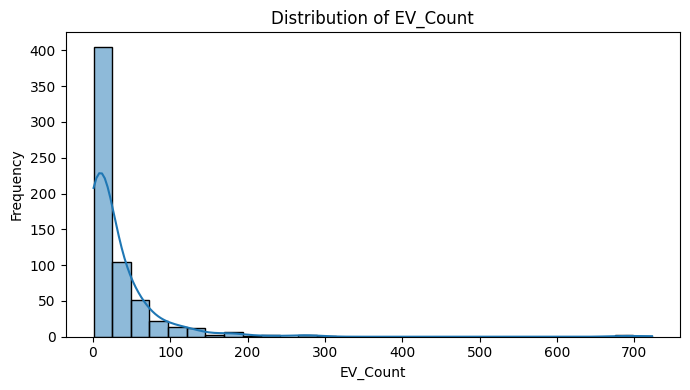

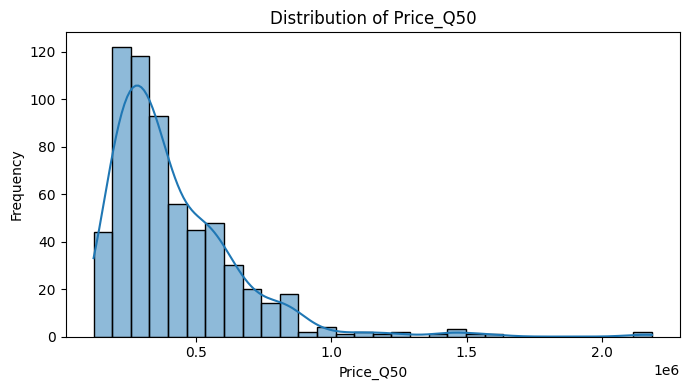

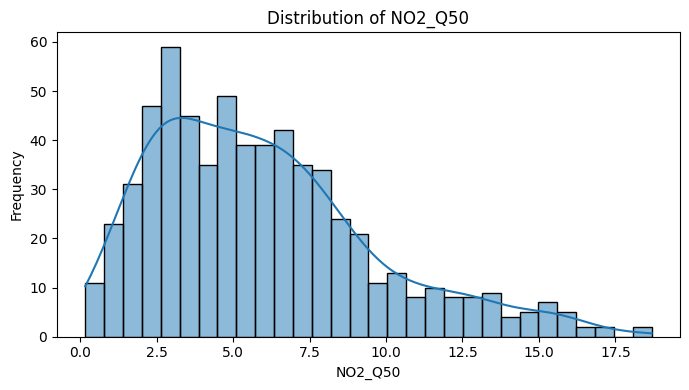

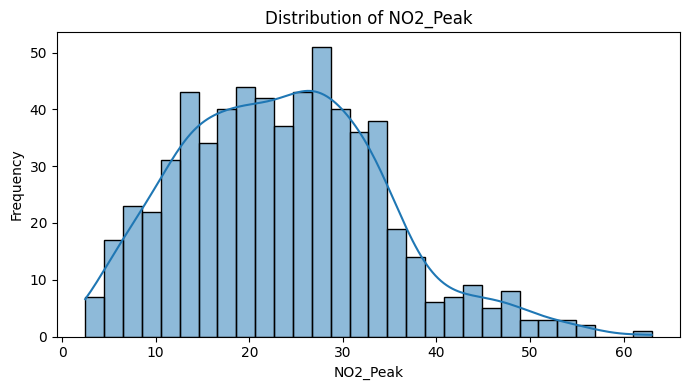

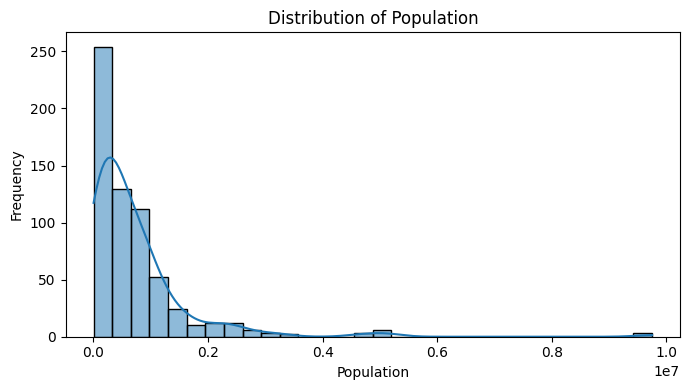

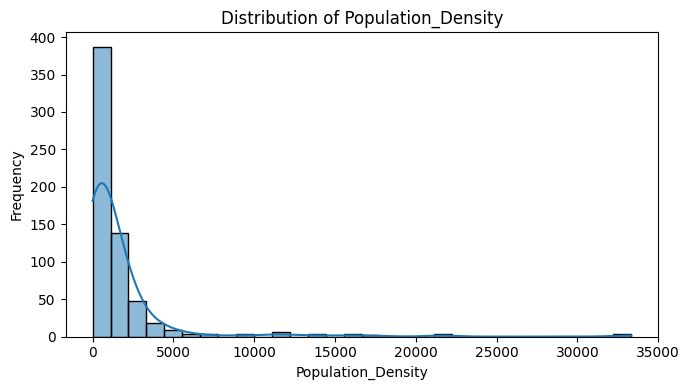

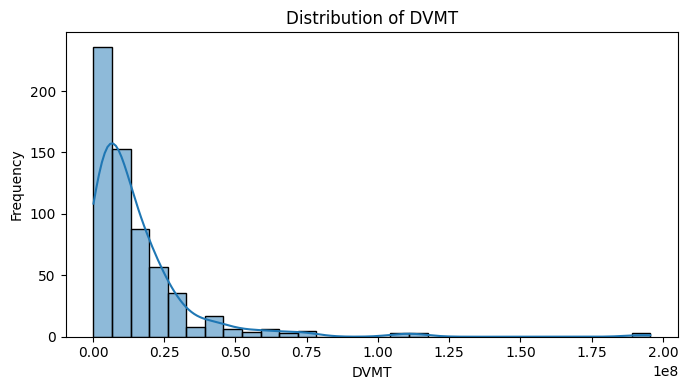

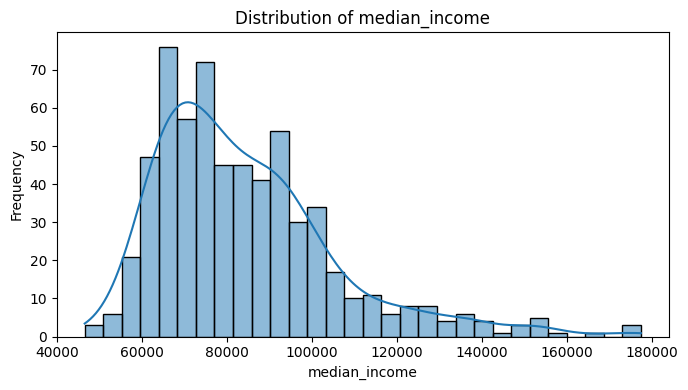

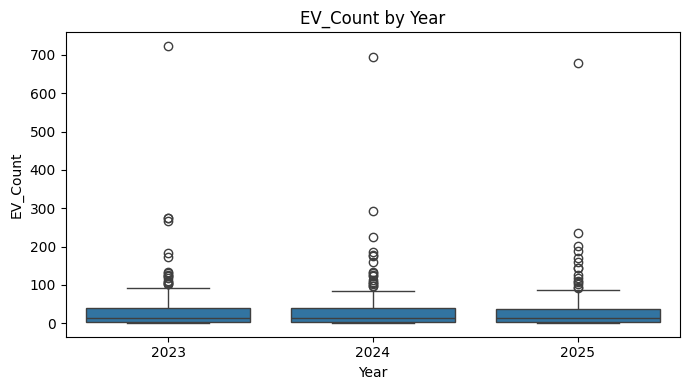

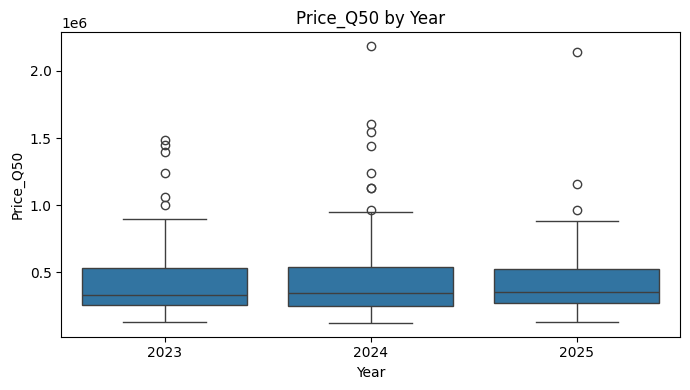

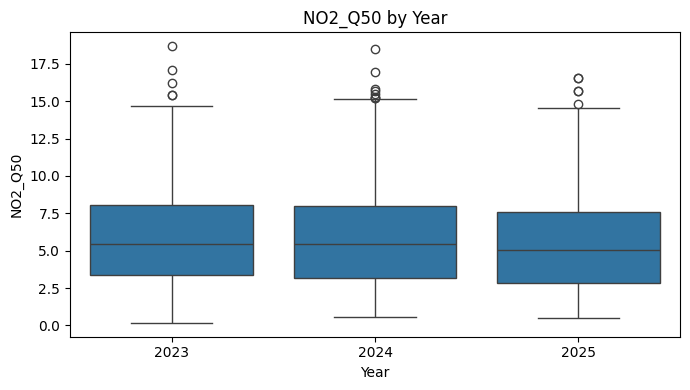

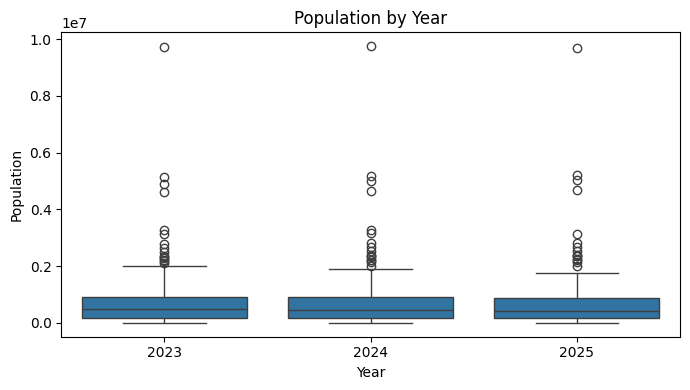

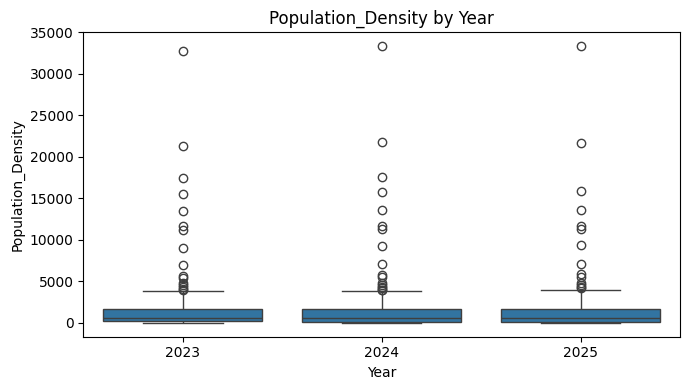

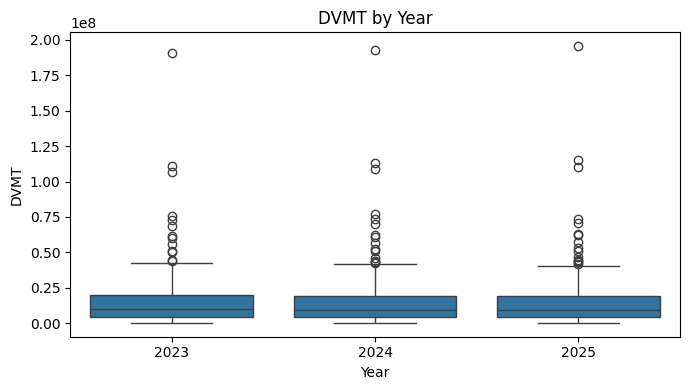

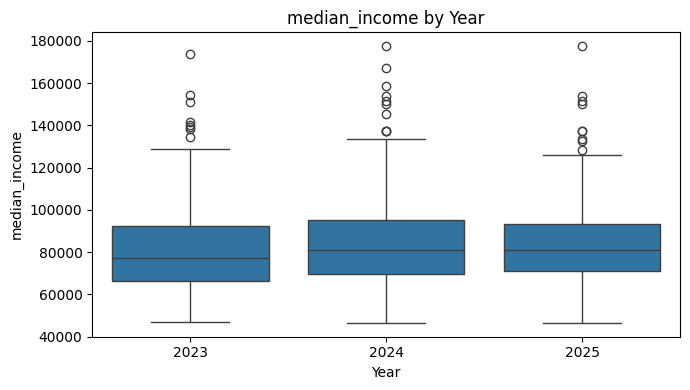


Yearly summary:


,Year,Counties,Avg_EV_Count,Median_Price,Median_NO2,Median_Population,Median_Population_Density,Median_DVMT,Median_Household_Income
0,2023,205,34.492683,332046.527600,5.462500,480816.0,617.482057,9.964152e+06,77215.0
1,2024,219,32.200913,344722.227000,5.441304,443749.0,577.122829,9.382749e+06,80840.5
2,2025,204,31.186275,351546.950979,5.068895,439132.5,589.922064,9.514512e+06,80878.0


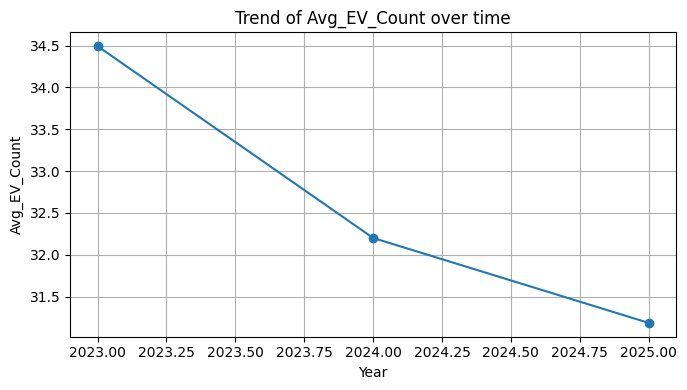

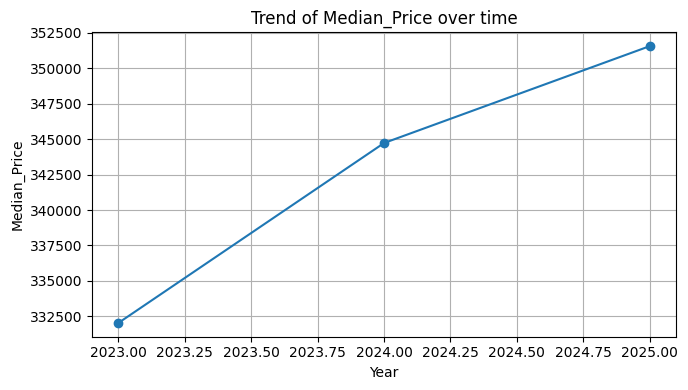

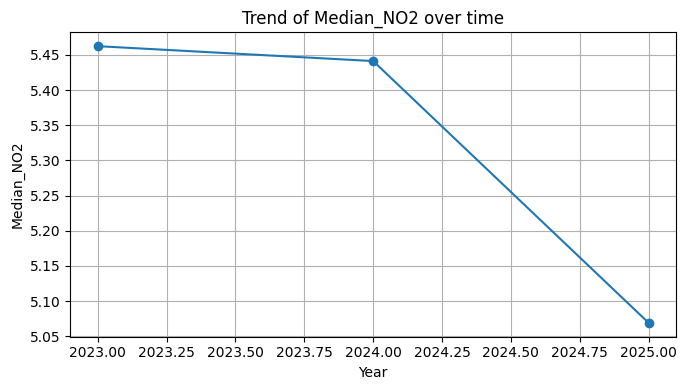

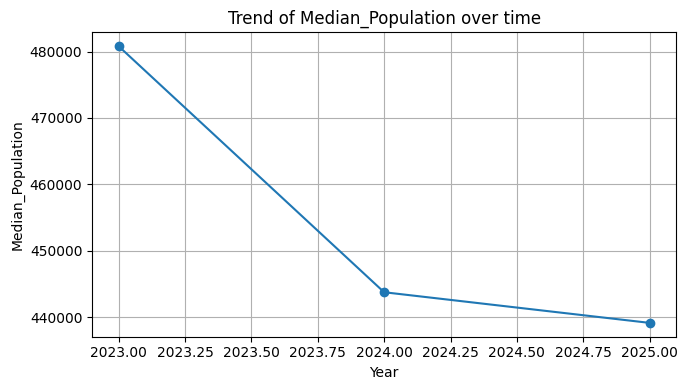

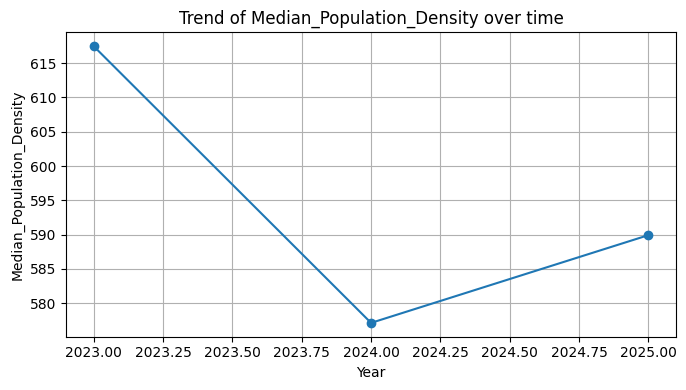

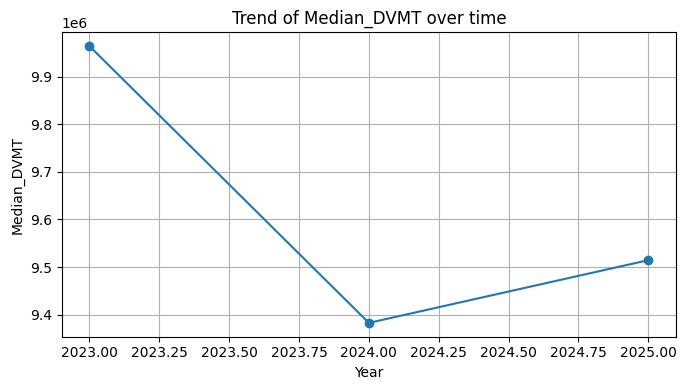

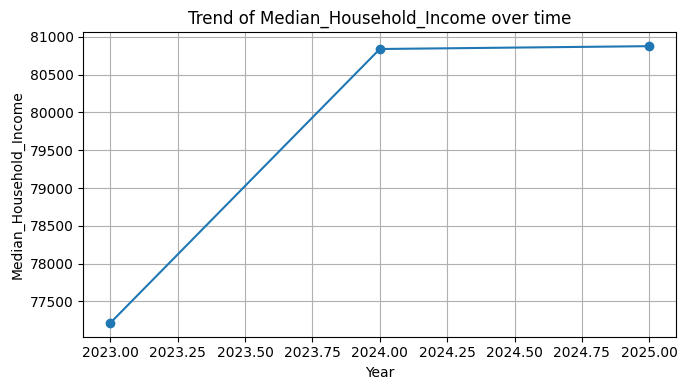

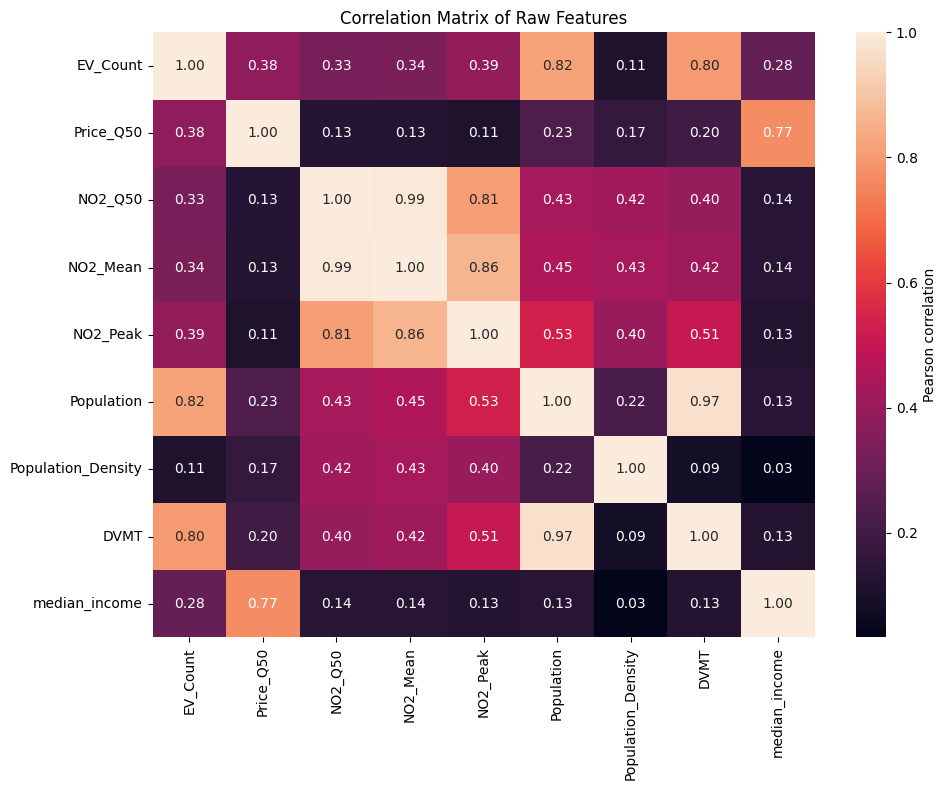

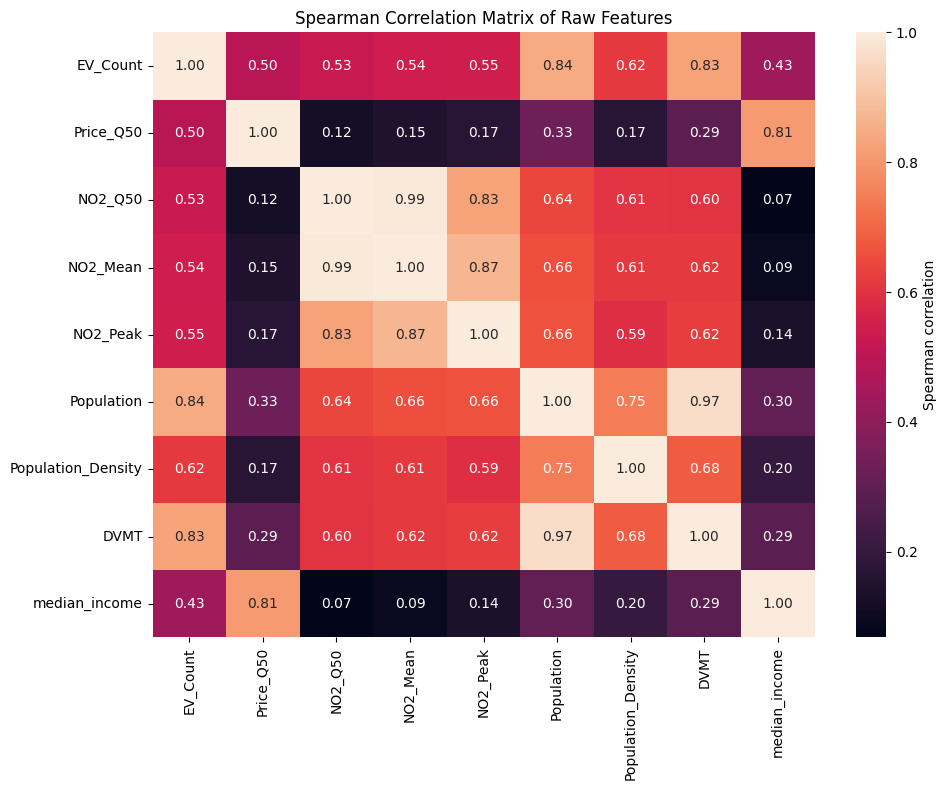

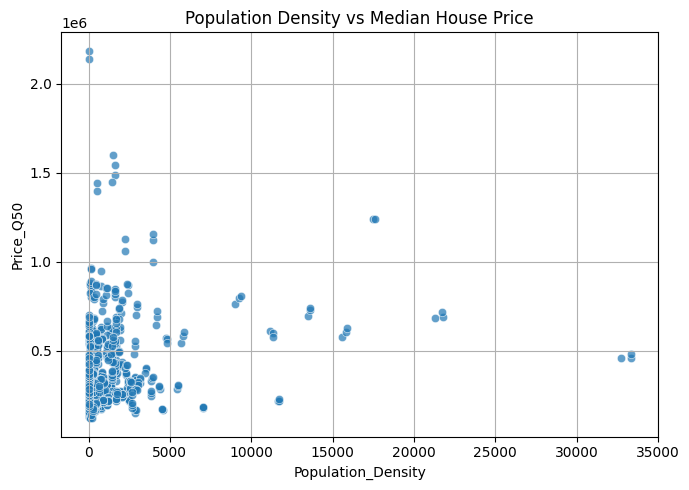

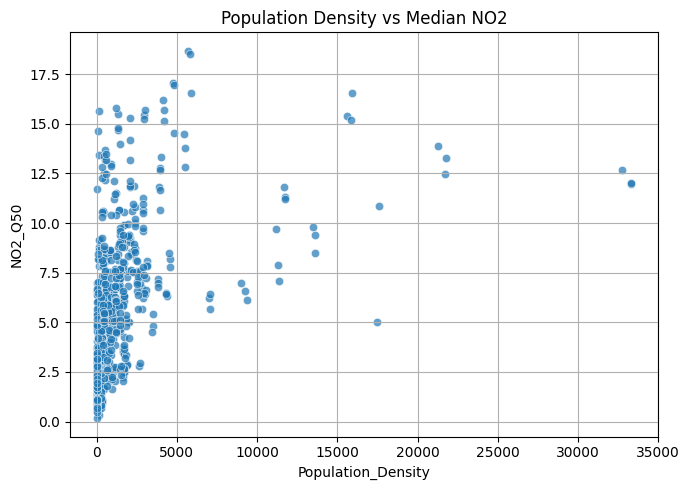

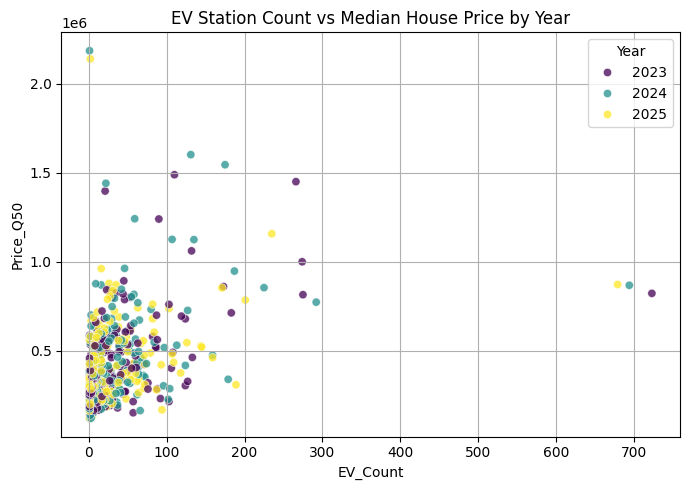

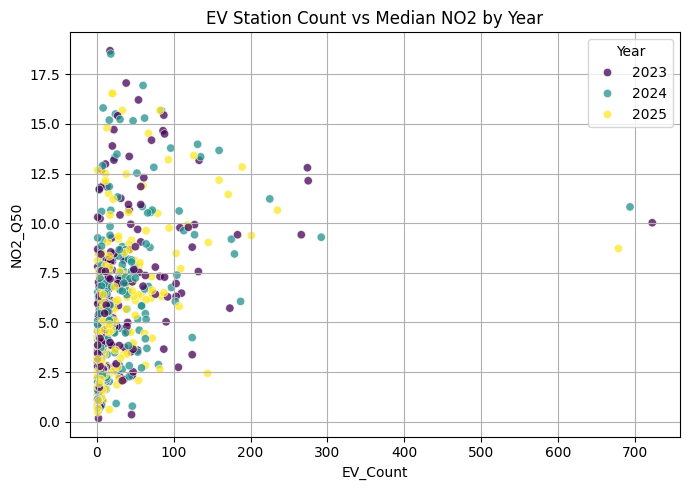

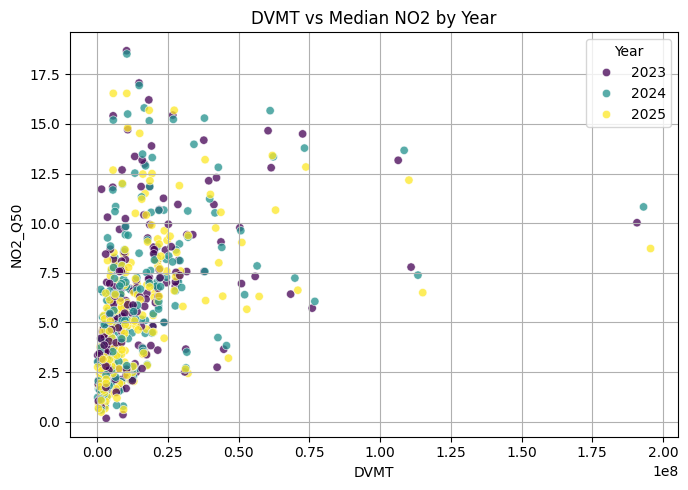

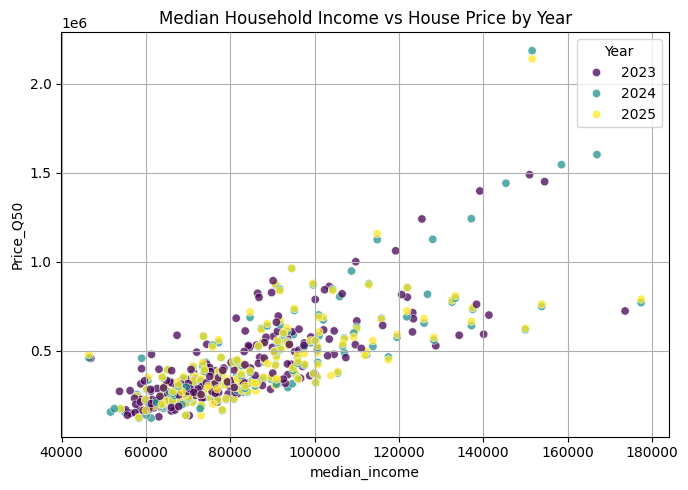


Feature pairs with absolute Pearson correlation >= 0.90:


,Feature_1,Feature_2,Absolute_Correlation
15,NO2_Q50,NO2_Mean,0.990589
31,Population,DVMT,0.970793



Highly skewed raw variables, using |skew| >= 1:


,mean,median,std,skew,kurtosis
EV_Count,3.261943e+01,1.300000e+01,6.235117e+01,6.656707,62.736176
EV_New_Stations,3.261943e+01,1.300000e+01,6.235117e+01,6.656707,62.736176
Population_Density,1.606898e+03,5.899221e+02,3.471457e+03,5.630450,39.422577
EV_per_100k,4.842739e+00,3.224174e+00,5.854709e+00,5.481140,47.005542
Population,7.310064e+05,4.515430e+05,1.015907e+06,4.635626,31.715490
VMT,5.698594e+09,3.538022e+09,7.561906e+09,4.429035,28.703153
DVMT,1.561259e+07,9.693212e+06,2.071755e+07,4.429035,28.703153
Land_Area_sqmi,1.554585e+03,7.626550e+02,2.300438e+03,3.834051,21.325255
EPA_County_Code,8.364968e+01,5.200000e+01,1.125803e+02,3.378880,13.896347
MunicipalCodeFIPS,8.364968e+01,5.200000e+01,1.125803e+02,3.378880,13.896347


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# 1. LOAD DATA
# =========================

df = pd.read_csv("final_dataset.csv")

# Standardise merge keys
df["fips"] = (
    df["fips"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)

df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst rows:")
display(df.head())


# =========================
# 2. BASIC DATASET STRUCTURE
# =========================

print("\nDataset info:")
df.info()

print("\nNumber of distinct counties:")
print(df["fips"].nunique())

print("\nRows per year:")
print(
    df["Year"]
    .value_counts()
    .sort_index()
)

print("\nDuplicate county-year rows:")
print(
    df.duplicated(
        subset=["fips", "Year"]
    ).sum()
)


# =========================
# 3. MISSING VALUES
# =========================

missing = (
    df.isna()
    .sum()
    .to_frame("Missing_Count")
)

missing["Missing_Percent"] = (
    missing["Missing_Count"] / len(df)
) * 100

missing = missing.sort_values(
    "Missing_Percent",
    ascending=False
)

print("\nMissing values:")
display(missing)


# =========================
# 4. NUMERIC SUMMARY STATISTICS
# =========================

numeric_cols = (
    df.select_dtypes(
        include=[np.number]
    )
    .columns
    .tolist()
)

print("\nNumeric summary:")
display(
    df[numeric_cols]
    .describe()
    .T
)


# =========================
# 17. COUNTY-LEVEL AVERAGES ACROSS YEARS
# =========================

county_aggregations = {
    "Years_Available": (
        "Year",
        "nunique"
    )
}

optional_county_metrics = {
    "Avg_EV_Count": (
        "EV_Count",
        "mean"
    ),
    "Avg_Price_Q50": (
        "Price_Q50",
        "mean"
    ),
    "Avg_NO2_Q50": (
        "NO2_Q50",
        "mean"
    ),
    "Avg_Population": (
        "Population",
        "mean"
    ),
    "Avg_Population_Density": (
        "Population_Density",
        "mean"
    ),
    "Land_Area": (
        "Land_Area",
        "first"
    ),
    "Avg_DVMT": (
        "DVMT",
        "mean"
    ),
    "Avg_Median_Income": (
        "median_income",
        "mean"
    )
}

for metric_name, aggregation in optional_county_metrics.items():

    source_column = aggregation[0]

    if source_column in df.columns:
        county_aggregations[metric_name] = aggregation


county_summary = (
    df.groupby(
        [
            "fips",
            "RegionName",
            "StateName"
        ],
        as_index=False
    )
    .agg(**county_aggregations)
)

print("\nCounty-level summary:")
display(
    county_summary.head()
)


# =========================
# 5. RAW FEATURES USED IN EDA
#
# Engineered features such as log_EV_Count and EV_per_100k
# are intentionally excluded at this stage.
#
# VMT is also excluded because VMT = DVMT × 365 and therefore
# contains the same statistical information as DVMT.
# =========================

eda_features = [
    "EV_Count",
    "EV_Growth_Rate",
    "Price_Q25",
    "Price_Q50",
    "Price_Q75",
    "Price_Growth_Pct",
    "NO2_Q25",
    "NO2_Q50",
    "NO2_Q75",
    "NO2_Mean",
    "NO2_Peak",
    "Population",
    "Land_Area",
    "Population_Density",
    "DVMT",
    "median_income"
]

eda_features = [
    col for col in eda_features
    if col in df.columns
]


# =========================
# 7. FEATURE DISTRIBUTIONS
#
# These histograms help identify skewness, unusual ranges,
# multimodality, and potential outliers.
# =========================

distribution_cols = [
    "EV_Count",
    "Price_Q50",
    "NO2_Q50",
    "NO2_Peak",
    "Population",
    "Land_Area",
    "Population_Density",
    "DVMT",
    "median_income"
]

distribution_cols = [
    col for col in distribution_cols
    if col in df.columns
]

for col in distribution_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


# =========================
# 8. BOXPLOTS BY YEAR
#
# Land area is excluded because it should remain almost
# constant for each county over time.
# =========================

boxplot_cols = [
    "EV_Count",
    "Price_Q50",
    "NO2_Q50",
    "Population",
    "Population_Density",
    "DVMT",
    "median_income"
]

boxplot_cols = [
    col for col in boxplot_cols
    if col in df.columns
]

for col in boxplot_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="Year",
        y=col
    )

    plt.title(f"{col} by Year")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


# =========================
# 9. YEARLY SUMMARY TABLE
# =========================

yearly_aggregations = {
    "Counties": (
        "fips",
        "nunique"
    )
}

optional_yearly_metrics = {
    "Avg_EV_Count": (
        "EV_Count",
        "mean"
    ),
    "Median_Price": (
        "Price_Q50",
        "median"
    ),
    "Median_NO2": (
        "NO2_Q50",
        "median"
    ),
    "Median_Population": (
        "Population",
        "median"
    ),
    "Median_Population_Density": (
        "Population_Density",
        "median"
    ),
    "Median_DVMT": (
        "DVMT",
        "median"
    ),
    "Median_Household_Income": (
        "median_income",
        "median"
    )
}

for metric_name, aggregation in optional_yearly_metrics.items():

    source_column = aggregation[0]

    if source_column in df.columns:
        yearly_aggregations[metric_name] = aggregation


yearly_summary = (
    df.groupby("Year")
    .agg(**yearly_aggregations)
    .reset_index()
)

print("\nYearly summary:")
display(yearly_summary)


# =========================
# 10. YEARLY TREND PLOTS
# =========================

trend_cols = [
    col for col in yearly_summary.columns
    if col not in ["Year", "Counties"]
]

for col in trend_cols:

    plt.figure(figsize=(7, 4))

    plt.plot(
        yearly_summary["Year"],
        yearly_summary[col],
        marker="o"
    )

    plt.xlabel("Year")
    plt.ylabel(col)
    plt.title(f"Trend of {col} over time")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =========================
# 11. CORRELATION MATRIX
#
# Only raw or directly measured variables are included.
# Engineered EV variables and VMT are excluded.
# =========================

corr_cols = [
    "EV_Count",
    "Price_Q50",
    "NO2_Q50",
    "NO2_Mean",
    "NO2_Peak",
    "Population",
    "Land_Area",
    "Population_Density",
    "DVMT",
    "median_income"
]

corr_cols = [
    col for col in corr_cols
    if col in df.columns
]

corr = (
    df[corr_cols]
    .corr(
        method="pearson"
    )
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=False,
    cbar_kws={
        "label": "Pearson correlation"
    }
)

plt.title("Correlation Matrix of Raw Features")
plt.tight_layout()
plt.show()


# =========================
# 12. SPEARMAN CORRELATION MATRIX
#
# Spearman correlation is useful when relationships may be
# monotonic but not linear, especially for skewed variables.
# =========================

spearman_corr = (
    df[corr_cols]
    .corr(
        method="spearman"
    )
)


plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    square=False,
    cbar_kws={
        "label": "Spearman correlation"
    }
)

plt.title("Spearman Correlation Matrix of Raw Features")
plt.tight_layout()
plt.show()


# =========================
# 14. NEW CONTROL-VARIABLE RELATIONSHIPS
#
# These plots explore whether traffic, urban density,
# land area, and income are associated with the outcomes.
# =========================

control_relationships = [
    (
        "Population_Density",
        "Price_Q50",
        "Population Density vs Median House Price"
    ),
    (
        "Population_Density",
        "NO2_Q50",
        "Population Density vs Median NO2"
    ),
    (
        "Land_Area",
        "Price_Q50",
        "County Land Area vs Median House Price"
    ),
    (
        "Land_Area",
        "NO2_Q50",
        "County Land Area vs Median NO2"
    )
]

for x_col, y_col, title in control_relationships:

    if x_col in df.columns and y_col in df.columns:

        plt.figure(figsize=(7, 5))

        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            alpha=0.7
        )

        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(title)
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# =========================
# 15. RELATIONSHIPS COLOURED BY YEAR
# =========================

year_relationships = [
    (
        "EV_Count",
        "Price_Q50",
        "EV Station Count vs Median House Price by Year"
    ),
    (
        "EV_Count",
        "NO2_Q50",
        "EV Station Count vs Median NO2 by Year"
    ),
    (
        "DVMT",
        "NO2_Q50",
        "DVMT vs Median NO2 by Year"
    ),
    (
        "median_income",
        "Price_Q50",
        "Median Household Income vs House Price by Year"
    )
]

for x_col, y_col, title in year_relationships:

    if x_col in df.columns and y_col in df.columns:

        plt.figure(figsize=(7, 5))

        sns.scatterplot(
            data=df,
            x=x_col,
            y=y_col,
            hue="Year",
            palette="viridis",
            alpha=0.75
        )

        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(title)
        plt.legend(title="Year")
        plt.grid(True)
        plt.tight_layout()
        plt.show()



# =========================
# 20. CHECK REDUNDANT OR HIGHLY CORRELATED FEATURES
#
# This identifies feature pairs with absolute Pearson
# correlation greater than or equal to 0.90.
# =========================

upper_triangle = (
    corr.abs()
    .where(
        np.triu(
            np.ones(
                corr.shape
            ),
            k=1
        ).astype(bool)
    )
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Absolute_Correlation"
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs[
            "Absolute_Correlation"
        ] >= 0.90
    ]
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

print(
    "\nFeature pairs with absolute Pearson correlation >= 0.90:"
)

display(high_corr_pairs)


# =========================
# 21. FINAL EDA NOTES
#
# These outputs support decisions made in the next feature
# engineering stage.
# =========================

feature_summary = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "std": df[numeric_cols].std(),
    "skew": df[numeric_cols].skew(),
    "kurtosis": df[numeric_cols].kurtosis()
})

print("\nHighly skewed raw variables, using |skew| >= 1:")

highly_skewed = (
    feature_summary[
        feature_summary["skew"].abs() >= 1
    ][
        [
            "mean",
            "median",
            "std",
            "skew",
            "kurtosis"
        ]
    ]
    .sort_values(
        "skew",
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(highly_skewed)


# Outlier Detection

### PCA

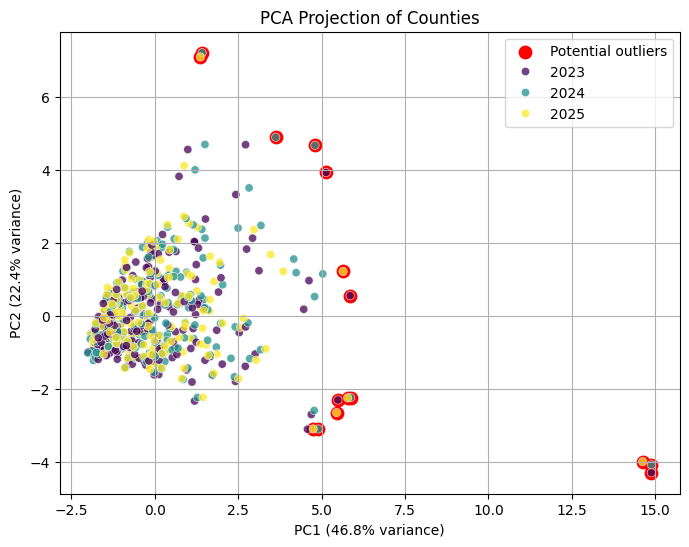

PCA detected 16 outliers.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# OUTLIER VISUALIZATION USING PCA
# =========================

pca_features = [
    "EV_Count",
    "Price_Q50",
    "NO2_Q50",
    "Population",
    "Land_Area",
    "Population_Density",
    "DVMT",
    "median_income"
]

pca_features = [c for c in pca_features if c in df.columns]

# Remove rows with missing values
pca_df = df[pca_features].dropna()

# Standardize
X = StandardScaler().fit_transform(pca_df)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Detect outliers using distance from PCA center
dist = np.sqrt((X_pca**2).sum(axis=1))

threshold = np.percentile(dist, 97.5)   # top 2.5% farthest points
outliers = dist > threshold

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[outliers,0],
    X_pca[outliers,1],
    color="red",
    s=80,
    label="Potential outliers"
)

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df.loc[pca_df.index, "Year"],
    palette="viridis",
    alpha=0.75
)


plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Projection of Counties")
plt.legend()
plt.grid(True)
plt.show()

print(f"PCA detected {outliers.sum()} outliers.")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

### Isolation Forest

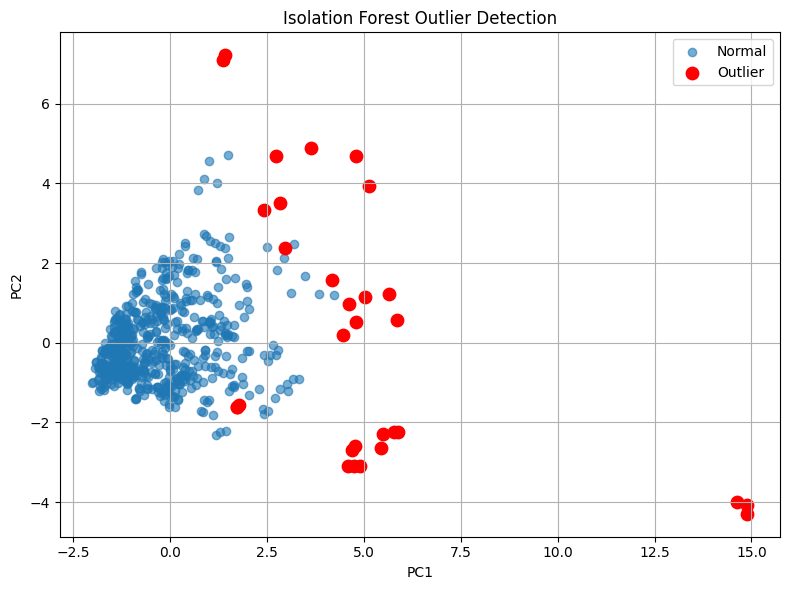

Isolation Forest detected 31 outliers.


In [ ]:
# =========================
# OUTLIER DETECTION - ISOLATION FOREST
# =========================

outlier_features = [
    "EV_Count",
    "Price_Q50",
    "NO2_Q50",
    "Population",
    "Land_Area",
    "Population_Density",
    "DVMT",
    "median_income"
]

outlier_features = [
    col for col in outlier_features
    if col in df.columns
]

X = df[outlier_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_labels = iso.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[iso_labels==1,0],
    X_pca[iso_labels==1,1],
    alpha=0.6,
    label="Normal"
)

plt.scatter(
    X_pca[iso_labels==-1,0],
    X_pca[iso_labels==-1,1],
    color="red",
    s=80,
    label="Outlier"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Outlier Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Isolation Forest detected {(iso_labels==-1).sum()} outliers.")

### LOF

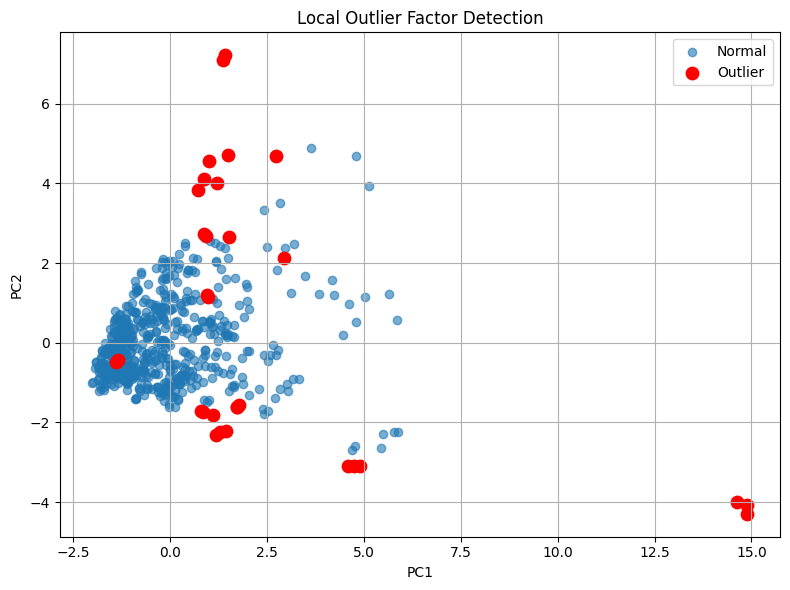

LOF detected 31 outliers.


In [ ]:
# =========================
# OUTLIER DETECTION - LOF
# =========================

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

lof_labels = lof.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[lof_labels==1,0],
    X_pca[lof_labels==1,1],
    alpha=0.6,
    label="Normal"
)

plt.scatter(
    X_pca[lof_labels==-1,0],
    X_pca[lof_labels==-1,1],
    color="red",
    s=80,
    label="Outlier"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Local Outlier Factor Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"LOF detected {(lof_labels==-1).sum()} outliers.")

In [ ]:
# Create a table with the detected outliers

X = df[outlier_features].dropna()

outlier_results = df.loc[X.index, [
    "fips",
    "RegionName",
    "StateName",
    "Year"
]].copy()

outlier_results["PCA"] = outliers
outlier_results["IsolationForest"] = (iso_labels == -1)
outlier_results["LOF"] = (lof_labels == -1)

outlier_results["Detected_By"] = (
    outlier_results[["PCA", "IsolationForest", "LOF"]]
    .sum(axis=1)
)

# Keep only rows detected by at least one method
outlier_results = outlier_results[
    outlier_results[["PCA", "IsolationForest", "LOF"]].any(axis=1)
]

print(f"Total unique outlier samples: {len(outlier_results)}")

display(
    outlier_results.sort_values(
        "Detected_By",
        ascending=False
    )
)

Total unique outlier samples: 50


,fips,RegionName,StateName,Year,PCA,IsolationForest,LOF,Detected_By
34,06037,Los Angeles County,CA,2023,True,True,True,3
35,06037,Los Angeles County,CA,2024,True,True,True,3
36,06037,Los Angeles County,CA,2025,True,True,True,3
509,48201,Harris County,TX,2024,True,True,True,3
627,56039,Teton County,WY,2025,True,True,True,3
626,56039,Teton County,WY,2024,True,True,True,3
510,48201,Harris County,TX,2025,True,True,True,3
3,04013,Maricopa County,AZ,2023,True,True,False,2
4,04013,Maricopa County,AZ,2024,True,True,False,2
5,04013,Maricopa County,AZ,2025,True,True,False,2


# EDA Handling & Log transformation

In [ ]:
import numpy as np


df = pd.read_csv("final_dataset.csv")

# =========================
# FEATURE ENGINEERING: LOG TRANSFORMATIONS
# =========================

# Create log-transformed features
df["log_EV_Count"] = np.log1p(df["EV_Count"])
df["log_Population"] = np.log1p(df["Population"])
df["log_Population_Density"] = np.log1p(df["Population_Density"])
df["log_Price_Q50"] = np.log(df["Price_Q50"])
df["log_DVMT"] = np.log1p(df["DVMT"])
df["log_Land_Area"] = np.log1p(df["Land_Area_sqmi"])

# EV_per_100k is assumed to already exist
# df["EV_per_100k"] = ...

# =========================
# CHECK SKEWNESS BEFORE AND AFTER
# =========================

transformations = {
    "EV_Count": "log_EV_Count",
    "Population": "log_Population",
    "Population_Density": "log_Population_Density",
    "Price_Q50": "log_Price_Q50",
    "DVMT": "log_DVMT",
    "Land_Area_sqmi": "log_Land_Area"
}

for original_col, transformed_col in transformations.items():
    print(f"\n{original_col}:")
    print(f"Before: {df[original_col].skew():.4f}")
    print(f"After : {df[transformed_col].skew():.4f}")

# =========================
# SAVE UPDATED DATASET
# =========================

df.to_csv("final_dataset_fixed.csv", index=False)



EV_Count:
Before: 6.6567
After : 0.2007

Population:
Before: 4.6356
After : -0.6849

Population_Density:
Before: 5.6304
After : -0.6174

Price_Q50:
Before: 2.5144
After : 0.4275

DVMT:
Before: 4.4290
After : -0.3906

Land_Area_sqmi:
Before: 3.8341
After : -0.0689


# Missing Data & Imputation

### Remove 10% and compare 2 approaches:
### log transformation -> imputation
### imputation -> log transformation

In [ ]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. SETUP
# =========================

df = pd.read_csv("final_dataset_fixed.csv")
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error


# =========================
# 1. SETUP
# =========================

df = pd.read_csv("final_dataset_fixed.csv")

# Raw variables that will be log-transformed
log_vars = [
    "EV_Count",
    "Population",
    "Population_Density",
    "Price_Q50",
    "DVMT",
    "Land_Area_sqmi"
]

# Variables that remain on their original scale
no2_vars = [
    "NO2_Q50",
    "NO2_Peak"
]

# Variables for which 10% will be artificially removed
target_impute_vars = log_vars + no2_vars

# Mapping from raw variables to their log-transformed versions
log_map = {
    "EV_Count": "log_EV_Count",
    "Population": "log_Population",
    "Population_Density": "log_Population_Density",
    "Price_Q50": "log_Price_Q50",
    "DVMT": "log_DVMT",
    "Land_Area_sqmi": "log_Land_Area"
}

# Keep only variables that actually exist in the dataset
log_vars = [col for col in log_vars if col in df.columns]
no2_vars = [col for col in no2_vars if col in df.columns]
target_impute_vars = log_vars + no2_vars

# Raw features used by Pipeline A
features_raw = target_impute_vars + ["Year"]
features_raw = [col for col in features_raw if col in df.columns]

# Convert relevant columns to numeric
for col in features_raw:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# =========================
# 2. CREATE LOG FEATURES
# =========================

# log1p is used for nonnegative variables that may contain zero
log1p_vars = [
    "EV_Count",
    "Population",
    "Population_Density",
    "DVMT",
    "Land_Area_sqmi"
]

for col in log1p_vars:
    if col in df.columns:
        df[log_map[col]] = np.log1p(df[col].clip(lower=0))

# Price_Q50 is positive
if "Price_Q50" in df.columns:
    df["log_Price_Q50"] = np.log(
        df["Price_Q50"].clip(lower=1)
    )

# Features used by Pipeline B
features_log = [
    log_map.get(col, col)
    for col in features_raw
]

print("Raw-space features:")
print(features_raw)

print("\nLog-space features:")
print(features_log)


# =========================
# 3. CREATE SAME MISSING INDICES
# =========================

np.random.seed(42)

missing_indices = {}

for col in target_impute_vars:
    available_indices = df.index[df[col].notna()]

    rng = np.random.RandomState(
        np.random.randint(0, 100000)
    )

    number_to_remove = max(
        1,
        int(round(len(available_indices) * 0.10))
    )

    selected_indices = rng.choice(
        available_indices,
        size=number_to_remove,
        replace=False
    )

    missing_indices[col] = selected_indices

print("\nArtificial missing values created:")

for col, indices in missing_indices.items():
    print(f"{col}: {len(indices)} removed")


# =========================
# 4. HELPER FUNCTIONS
# =========================

def rmse(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )


def safe_log(series, column):
    """
    Apply the same transformation used during feature engineering.
    """

    if column == "Price_Q50":
        return np.log(series.clip(lower=1))

    if column in log1p_vars:
        return np.log1p(series.clip(lower=0))

    return series


# =========================
# 5. PIPELINE A:
# IMPUTE RAW → LOG
# =========================

def evaluate_pipeline_A(imputer, imputer_name):

    df_missing = df[features_raw].copy()

    # Remove 10% from the raw variables
    for col in target_impute_vars:
        df_missing.loc[
            missing_indices[col],
            col
        ] = np.nan

    # Impute in the original feature space
    imputed_array = imputer.fit_transform(df_missing)

    df_imputed = pd.DataFrame(
        imputed_array,
        columns=features_raw,
        index=df.index
    )

    results = []

    for col in target_impute_vars:
        indices = missing_indices[col]

        if col in log_vars:
            # Transform the true and imputed raw values,
            # then compare them in log-space
            y_true = safe_log(
                df.loc[indices, col],
                col
            )

            y_pred = safe_log(
                df_imputed.loc[indices, col],
                col
            )

            evaluation_space = "log-space"

        else:
            # NO2 variables stay on their original scale
            y_true = df.loc[indices, col]
            y_pred = df_imputed.loc[indices, col]

            evaluation_space = "original-scale"

        results.append({
            "Pipeline": "Impute → Log",
            "Method": imputer_name,
            "Variable": col,
            "Evaluation_Space": evaluation_space,
            "MAE": mean_absolute_error(
                y_true,
                y_pred
            ),
            "RMSE": rmse(
                y_true,
                y_pred
            )
        })

    return results


# =========================
# 6. PIPELINE B:
# LOG → IMPUTE
# =========================

def evaluate_pipeline_B(imputer, imputer_name):

    df_missing = df[features_log].copy()

    # Remove the same observations from the transformed columns
    for raw_col in target_impute_vars:

        column_to_remove = log_map.get(
            raw_col,
            raw_col
        )

        df_missing.loc[
            missing_indices[raw_col],
            column_to_remove
        ] = np.nan

    # Impute directly in log-space
    imputed_array = imputer.fit_transform(df_missing)

    df_imputed = pd.DataFrame(
        imputed_array,
        columns=features_log,
        index=df.index
    )

    results = []

    for raw_col in target_impute_vars:
        indices = missing_indices[raw_col]

        if raw_col in log_vars:
            log_col = log_map[raw_col]

            y_true = df.loc[
                indices,
                log_col
            ]

            y_pred = df_imputed.loc[
                indices,
                log_col
            ]

            evaluation_space = "log-space"

        else:
            y_true = df.loc[
                indices,
                raw_col
            ]

            y_pred = df_imputed.loc[
                indices,
                raw_col
            ]

            evaluation_space = "original-scale"

        results.append({
            "Pipeline": "Log → Impute",
            "Method": imputer_name,
            "Variable": raw_col,
            "Evaluation_Space": evaluation_space,
            "MAE": mean_absolute_error(
                y_true,
                y_pred
            ),
            "RMSE": rmse(
                y_true,
                y_pred
            )
        })

    return results


# =========================
# 7. DEFINE IMPUTERS
# =========================

imputers = {
    "Mean": SimpleImputer(
        strategy="mean"
    ),

    "Median": SimpleImputer(
        strategy="median"
    ),

    "KNN": KNNImputer(
        n_neighbors=5
    ),

    "MICE": IterativeImputer(
        random_state=42,
        max_iter=20,
        sample_posterior=False
    )
}


# =========================
# 8. RUN EXPERIMENT
# =========================

all_results = []

for name, imputer in imputers.items():
    all_results.extend(
        evaluate_pipeline_A(
            imputer,
            name
        )
    )

for name, imputer in imputers.items():
    all_results.extend(
        evaluate_pipeline_B(
            imputer,
            name
        )
    )

results_df = pd.DataFrame(all_results)


# =========================
# 9. TABLE 1:
# PIPELINE COMPARISON
# =========================

summary_log_vars = (
    results_df[
        results_df["Variable"].isin(log_vars)
    ]
    .groupby(
        ["Pipeline", "Method"],
        as_index=False
    )
    .agg({
        "MAE": "mean",
        "RMSE": "mean"
    })
    .round(4)
    .sort_values("RMSE")
)

print(
    "\nTable 1: Pipeline Comparison "
    "for Log-Transformed Variables"
)

display(summary_log_vars)


# =========================
# 10. TABLE 2:
# RESULTS BY VARIABLE
# =========================

summary_by_variable = (
    results_df[
        results_df["Variable"].isin(log_vars)
    ]
    .groupby(
        ["Variable", "Pipeline", "Method"],
        as_index=False
    )
    .agg({
        "MAE": "mean",
        "RMSE": "mean"
    })
    .round(4)
    .sort_values(
        ["Variable", "RMSE"]
    )
)

print(
    "\nTable 2: Pipeline and Imputation "
    "Comparison by Log-Transformed Variable"
)

display(summary_by_variable)


# =========================
# 11. TABLE 3:
# NO2 IMPUTATION COMPARISON
# =========================

summary_no2 = (
    results_df[
        results_df["Variable"].isin(no2_vars)
    ]
    .groupby(
        "Method",
        as_index=False
    )
    .agg({
        "MAE": "mean",
        "RMSE": "mean"
    })
    .round(4)
    .sort_values("RMSE")
)

print(
    "\nTable 3: NO2 Imputation "
    "Method Comparison"
)

display(summary_no2)


# =========================
# 12. SAVE RESULTS
# =========================

summary_log_vars.to_csv(
    "table1_pipeline_comparison_log_variables.csv",
    index=False
)

summary_by_variable.to_csv(
    "table2_pipeline_comparison_by_variable.csv",
    index=False
)

summary_no2.to_csv(
    "table3_no2_imputation_methods.csv",
    index=False
)

results_df.to_csv(
    "all_imputation_experiment_results.csv",
    index=False
)

print("\nSaved:")
print("table1_pipeline_comparison_log_variables.csv")
print("table2_pipeline_comparison_by_variable.csv")
print("table3_no2_imputation_methods.csv")
print("all_imputation_experiment_results.csv")

Raw-space features:
['EV_Count', 'Population', 'Population_Density', 'Price_Q50', 'DVMT', 'Land_Area_sqmi', 'NO2_Q50', 'NO2_Peak', 'Year']

Log-space features:
['log_EV_Count', 'log_Population', 'log_Population_Density', 'log_Price_Q50', 'log_DVMT', 'log_Land_Area', 'NO2_Q50', 'NO2_Peak', 'Year']

Artificial missing values created:
EV_Count: 63 removed
Population: 63 removed
Population_Density: 63 removed
Price_Q50: 63 removed
DVMT: 63 removed
Land_Area_sqmi: 63 removed
NO2_Q50: 63 removed
NO2_Peak: 63 removed

Table 1: Pipeline Comparison for Log-Transformed Variables


,Pipeline,Method,MAE,RMSE
5,Log → Impute,MICE,0.2417,0.3851
4,Log → Impute,KNN,0.4552,0.6044
0,Impute → Log,KNN,0.7934,1.0598
6,Log → Impute,Mean,0.9622,1.1952
3,Impute → Log,Median,0.9516,1.1960
7,Log → Impute,Median,0.9516,1.1960
2,Impute → Log,Mean,1.0626,1.3614
1,Impute → Log,MICE,0.9539,1.4522



Table 2: Pipeline and Imputation Comparison by Log-Transformed Variable


,Variable,Pipeline,Method,MAE,RMSE
5,DVMT,Log → Impute,MICE,0.2046,0.2740
1,DVMT,Impute → Log,MICE,0.2662,0.4139
4,DVMT,Log → Impute,KNN,0.3804,0.4708
0,DVMT,Impute → Log,KNN,0.7804,0.9667
3,DVMT,Impute → Log,Median,0.8415,1.0746
7,DVMT,Log → Impute,Median,0.8415,1.0746
6,DVMT,Log → Impute,Mean,0.8503,1.0992
2,DVMT,Impute → Log,Mean,0.8910,1.1072
13,EV_Count,Log → Impute,MICE,0.5159,0.6569
12,EV_Count,Log → Impute,KNN,0.5531,0.7258



Table 3: NO2 Imputation Method Comparison


,Method,MAE,RMSE
1,MICE,3.3167,4.3347
0,KNN,4.3979,5.8333
2,Mean,6.0294,7.5372
3,Median,6.0109,7.5467



Saved:
table1_pipeline_comparison_log_variables.csv
table2_pipeline_comparison_by_variable.csv
table3_no2_imputation_methods.csv
all_imputation_experiment_results.csv


In [ ]:
# =========================
# 9. AGGREGATED RESULTS:
# LOG-TRANSFORMED VARIABLES
# =========================

summary_log_vars = (
    results_df[
        results_df["Variable"].isin(log_vars)
    ]
    .groupby(
        ["Pipeline", "Method"],
        as_index=False
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean")
    )
    .round(4)
    .sort_values("Mean_RMSE")
)

print(
    "\nTable 1: Aggregated Pipeline Comparison "
    "for Log-Transformed Variables"
)

display(summary_log_vars)


# =========================
# 10. AGGREGATED RESULTS:
# NO2 VARIABLES
# =========================

# NO2 is not log-transformed, so the two pipelines are identical
# in terms of preprocessing. We therefore aggregate only by method.

summary_no2 = (
    results_df[
        results_df["Variable"].isin(no2_vars)
    ]
    .groupby(
        "Method",
        as_index=False
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean")
    )
    .round(4)
    .sort_values("Mean_RMSE")
)

print(
    "\nTable 2: Aggregated NO2 "
    "Imputation Method Comparison"
)

display(summary_no2)


# =========================
# 11. OPTIONAL:
# BEST RESULT FROM EACH TABLE
# =========================

best_log_result = summary_log_vars.iloc[0]

print("\nBest preprocessing and imputation combination:")
print(
    f"{best_log_result['Pipeline']} with "
    f"{best_log_result['Method']} "
    f"(Mean RMSE = {best_log_result['Mean_RMSE']})"
)

best_no2_result = summary_no2.iloc[0]

print("\nBest NO2 imputation method:")
print(
    f"{best_no2_result['Method']} "
    f"(Mean RMSE = {best_no2_result['Mean_RMSE']})"
)


# =========================
# 12. SAVE FINAL TABLES
# =========================

summary_log_vars.to_csv(
    "table1_aggregated_pipeline_comparison.csv",
    index=False
)

summary_no2.to_csv(
    "table2_aggregated_no2_imputation.csv",
    index=False
)

# Keep the full detailed results for internal inspection
results_df.to_csv(
    "all_imputation_experiment_results.csv",
    index=False
)

print("\nSaved:")
print("table1_aggregated_pipeline_comparison.csv")
print("table2_aggregated_no2_imputation.csv")
print("all_imputation_experiment_results.csv")


Table 1: Aggregated Pipeline Comparison for Log-Transformed Variables


,Pipeline,Method,Mean_MAE,Mean_RMSE
5,Log → Impute,MICE,0.2417,0.3851
4,Log → Impute,KNN,0.4552,0.6044
0,Impute → Log,KNN,0.7934,1.0598
6,Log → Impute,Mean,0.9622,1.1952
3,Impute → Log,Median,0.9516,1.1960
7,Log → Impute,Median,0.9516,1.1960
2,Impute → Log,Mean,1.0626,1.3614
1,Impute → Log,MICE,0.9539,1.4522



Table 2: Aggregated NO2 Imputation Method Comparison


,Method,Mean_MAE,Mean_RMSE
1,MICE,3.3167,4.3347
0,KNN,4.3979,5.8333
2,Mean,6.0294,7.5372
3,Median,6.0109,7.5467



Best preprocessing and imputation combination:
Log → Impute with MICE (Mean RMSE = 0.3851)

Best NO2 imputation method:
MICE (Mean RMSE = 4.3347)

Saved:
table1_aggregated_pipeline_comparison.csv
table2_aggregated_no2_imputation.csv
all_imputation_experiment_results.csv


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 10. COLLECT IMPUTED VALUES
# =========================

plot_records = []


def collect_imputed_values_pipeline_A(imputer, imputer_name):
    """
    Pipeline A:
    Impute raw values first, then apply the log transformation.
    """

    df_missing = df[features_raw].copy()

    # Remove the same artificial 10% of observations
    for col in target_impute_vars:
        df_missing.loc[missing_indices[col], col] = np.nan

    # Impute raw values
    imputed_array = imputer.fit_transform(df_missing)

    df_imputed = pd.DataFrame(
        imputed_array,
        columns=features_raw,
        index=df.index
    )

    for raw_col in target_impute_vars:
        idx = missing_indices[raw_col]

        if raw_col in log_vars:
            # Compare in log-space
            y_true = safe_log(
                df.loc[idx, raw_col],
                raw_col
            )

            y_pred = safe_log(
                df_imputed.loc[idx, raw_col],
                raw_col
            )

            variable_name = log_map[raw_col]

        else:
            # NO2 variables stay in their original scale
            y_true = df.loc[idx, raw_col]
            y_pred = df_imputed.loc[idx, raw_col]

            variable_name = raw_col

        for row_index in idx:
            plot_records.append({
                "Pipeline": "Impute → Log",
                "Method": imputer_name,
                "Variable": variable_name,
                "True": y_true.loc[row_index],
                "Imputed": y_pred.loc[row_index]
            })


def collect_imputed_values_pipeline_B(imputer, imputer_name):
    """
    Pipeline B:
    Apply the log transformation first, then impute.
    """

    df_missing = df[features_log].copy()

    # Remove the same artificial 10% of observations
    for raw_col in target_impute_vars:
        transformed_col = log_map.get(raw_col, raw_col)

        df_missing.loc[
            missing_indices[raw_col],
            transformed_col
        ] = np.nan

    # Impute transformed values
    imputed_array = imputer.fit_transform(df_missing)

    df_imputed = pd.DataFrame(
        imputed_array,
        columns=features_log,
        index=df.index
    )

    for raw_col in target_impute_vars:
        idx = missing_indices[raw_col]
        variable_name = log_map.get(raw_col, raw_col)

        y_true = df.loc[idx, variable_name]
        y_pred = df_imputed.loc[idx, variable_name]

        for row_index in idx:
            plot_records.append({
                "Pipeline": "Log → Impute",
                "Method": imputer_name,
                "Variable": variable_name,
                "True": y_true.loc[row_index],
                "Imputed": y_pred.loc[row_index]
            })


# Run both pipelines using all methods
for method_name, imputer in imputers.items():
    collect_imputed_values_pipeline_A(
        imputer,
        method_name
    )

for method_name, imputer in imputers.items():
    collect_imputed_values_pipeline_B(
        imputer,
        method_name
    )

plot_df = pd.DataFrame(plot_records)

In [ ]:
# =========================
# 11. TRUE VS IMPUTED PLOTS
# =========================

def plot_true_vs_imputed(
    variable,
    pipeline,
    methods=("MICE", "KNN", "Mean", "Median")
):
    temp = plot_df[
        (plot_df["Variable"] == variable) &
        (plot_df["Pipeline"] == pipeline) &
        (plot_df["Method"].isin(methods))
    ].copy()

    if temp.empty:
        print(
            f"No data found for variable '{variable}' "
            f"and pipeline '{pipeline}'."
        )
        return

    plt.figure(figsize=(10, 6))

    markers = {
        "MICE": "o",
        "KNN": "s",
        "Mean": "^",
        "Median": "D"
    }

    for method in methods:
        sub = temp[temp["Method"] == method]

        if sub.empty:
            continue

        mae_value = mean_absolute_error(
            sub["True"],
            sub["Imputed"]
        )

        rmse_value = rmse(
            sub["True"],
            sub["Imputed"]
        )

        plt.scatter(
            sub["True"],
            sub["Imputed"],
            alpha=0.65,
            marker=markers.get(method, "o"),
            label=(
                f"{method} "
                f"(MAE={mae_value:.3f}, "
                f"RMSE={rmse_value:.3f})"
            )
        )

    min_value = min(
        temp["True"].min(),
        temp["Imputed"].min()
    )

    max_value = max(
        temp["True"].max(),
        temp["Imputed"].max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=2,
        label="Perfect imputation"
    )

    plt.title(
        f"True vs Imputed Values: {variable}\n"
        f"Pipeline: {pipeline}"
    )

    plt.xlabel(f"True {variable}")
    plt.ylabel(f"Imputed {variable}")

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

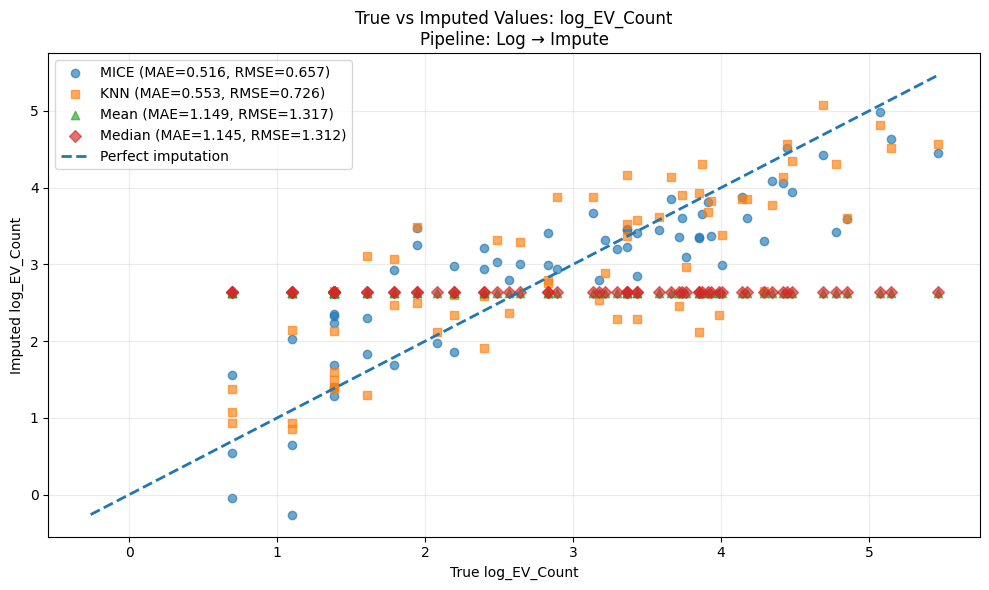

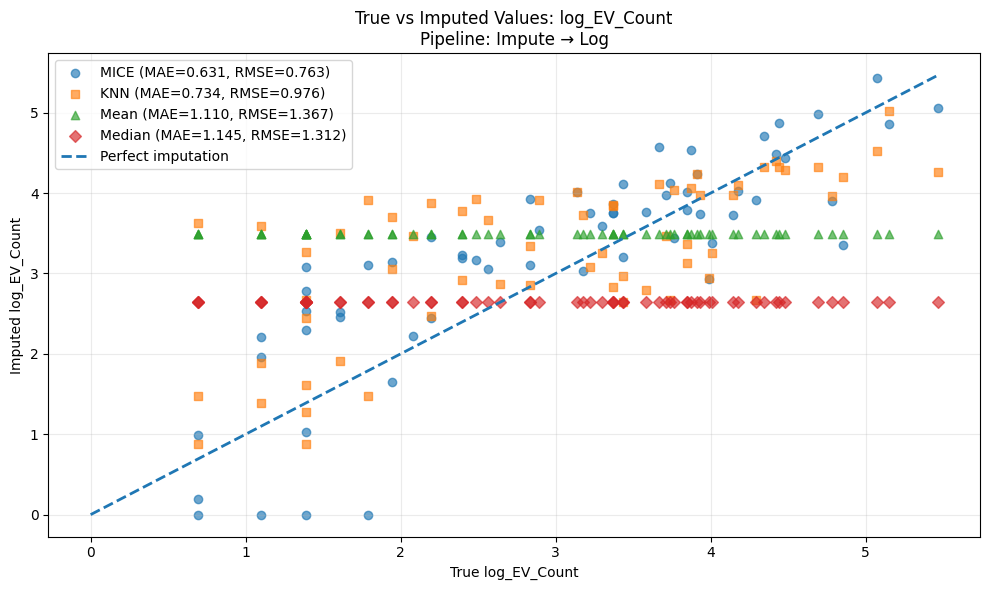

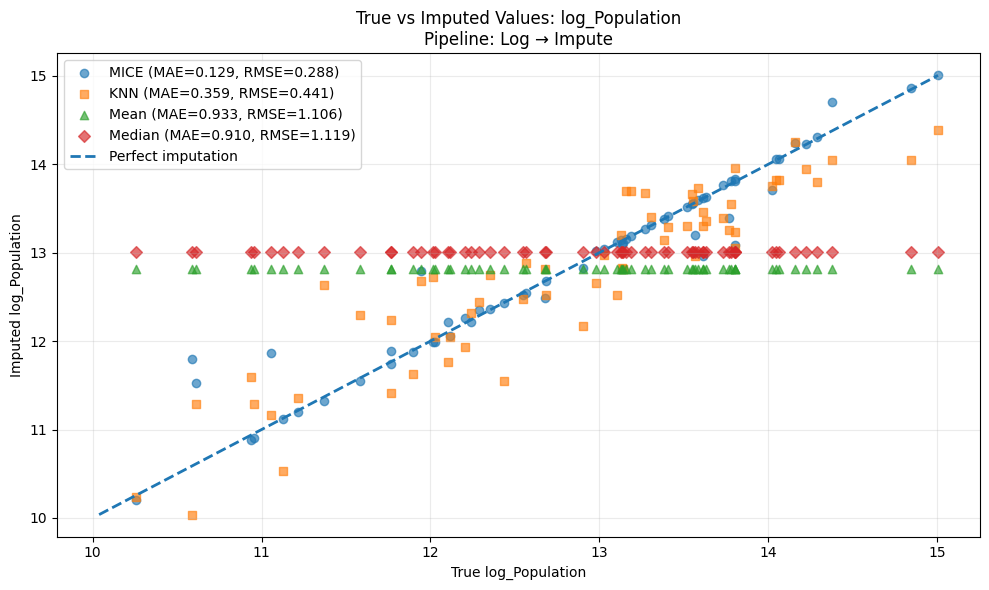

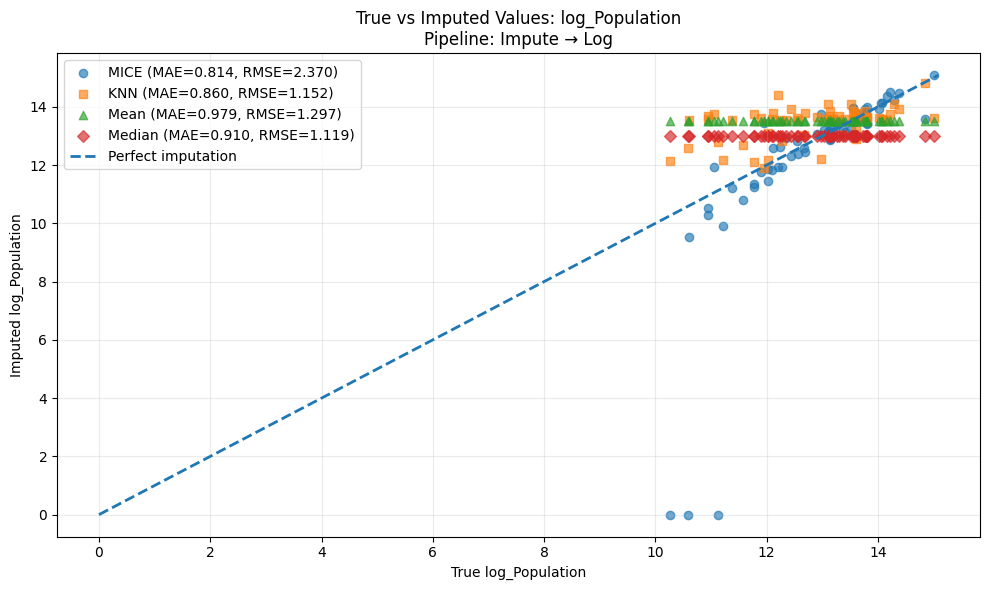

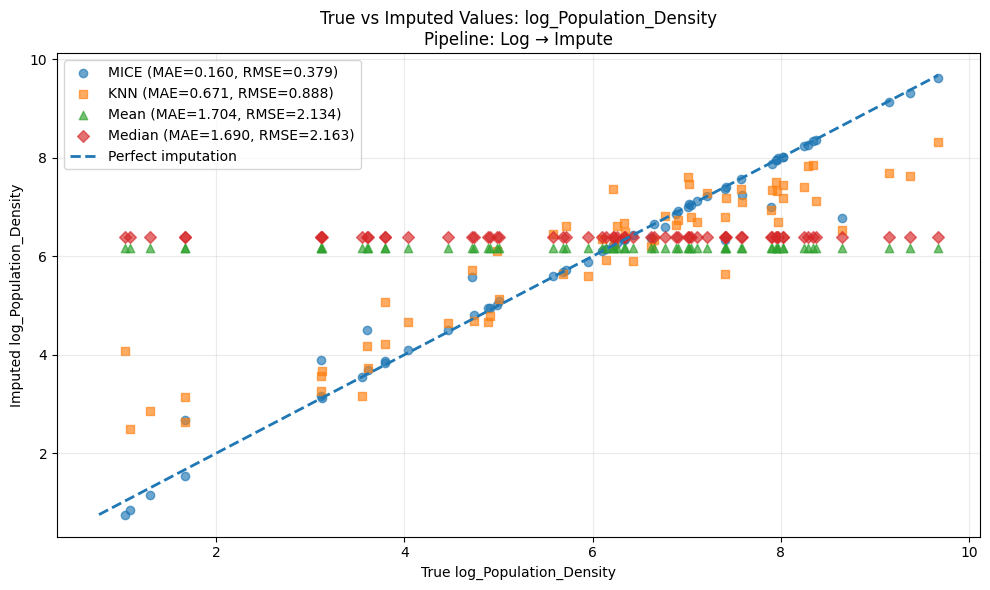

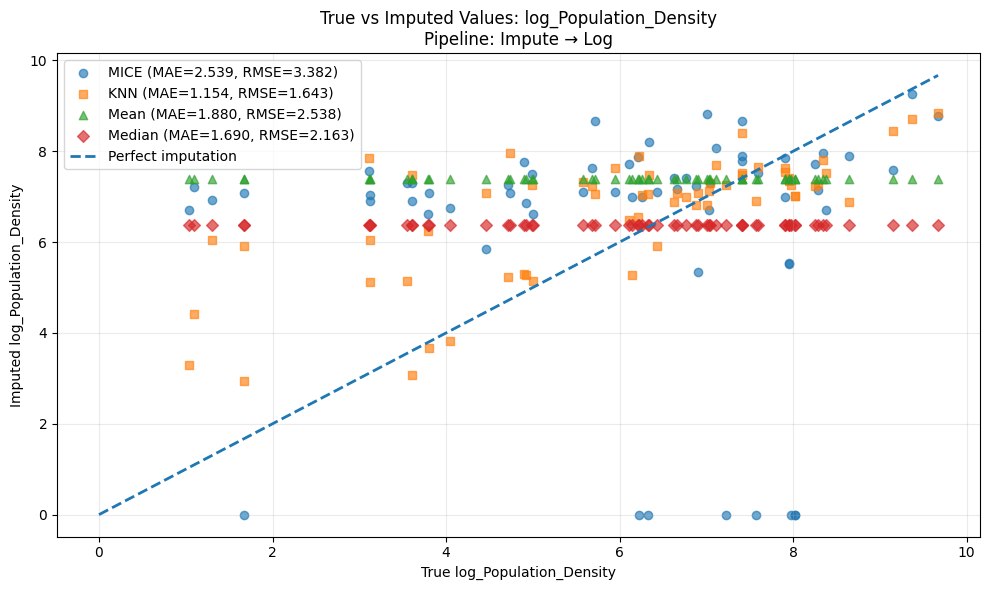

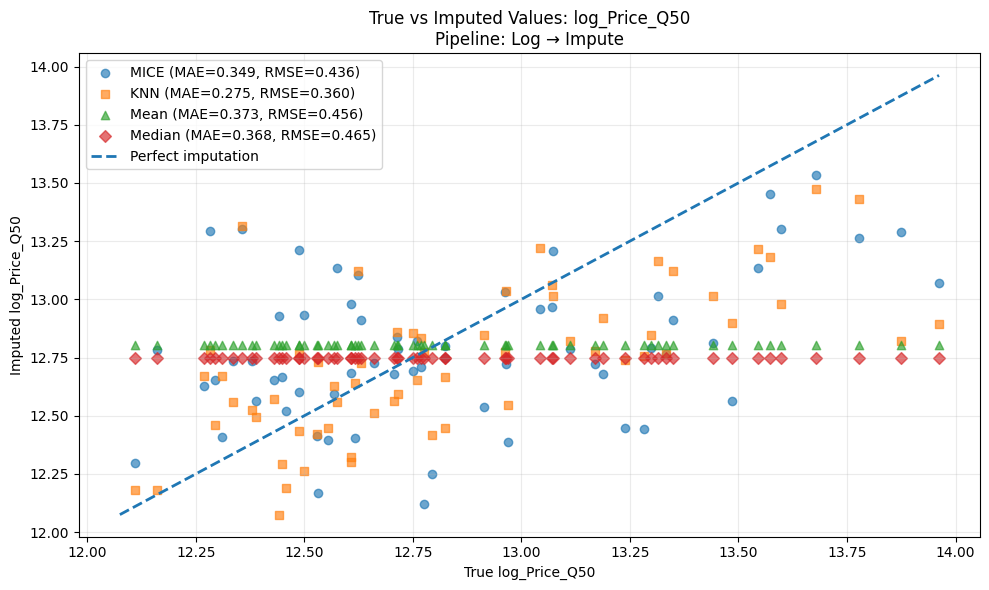

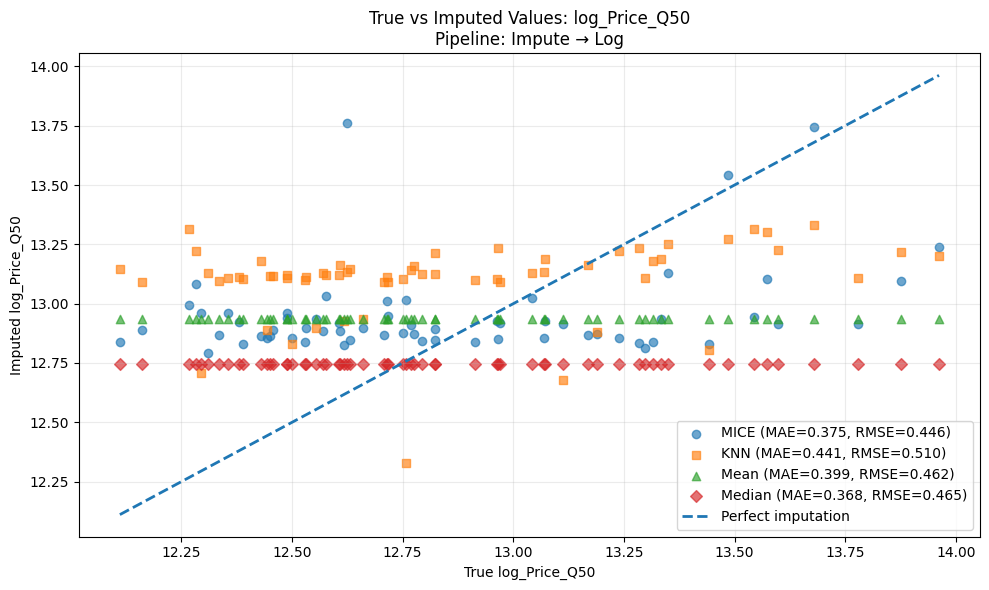

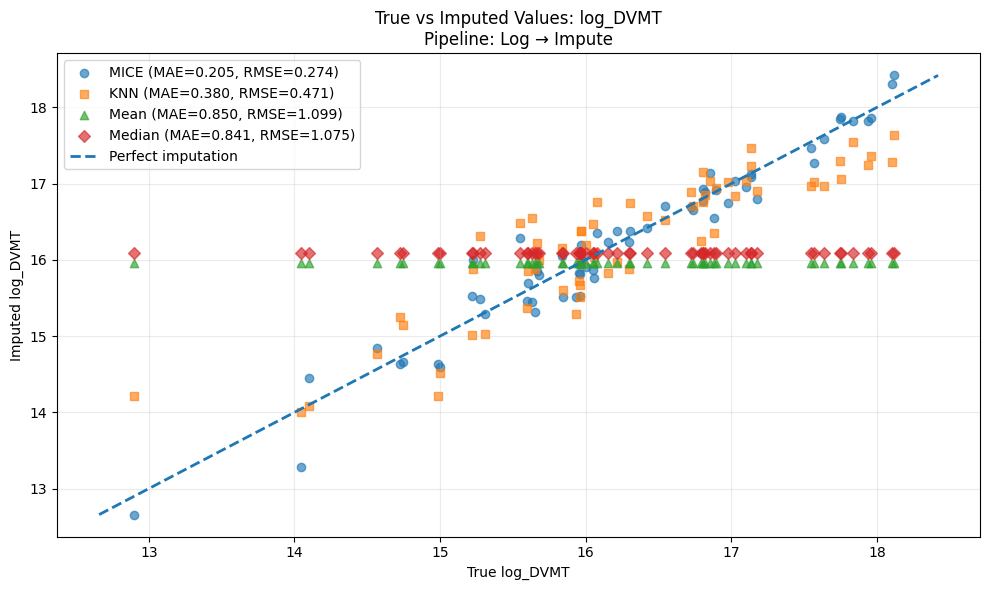

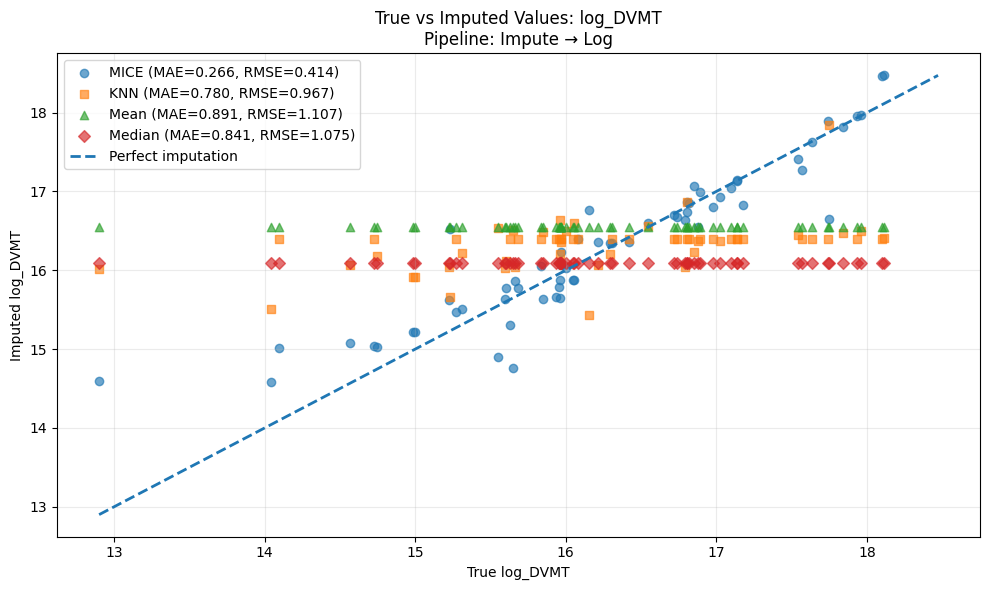

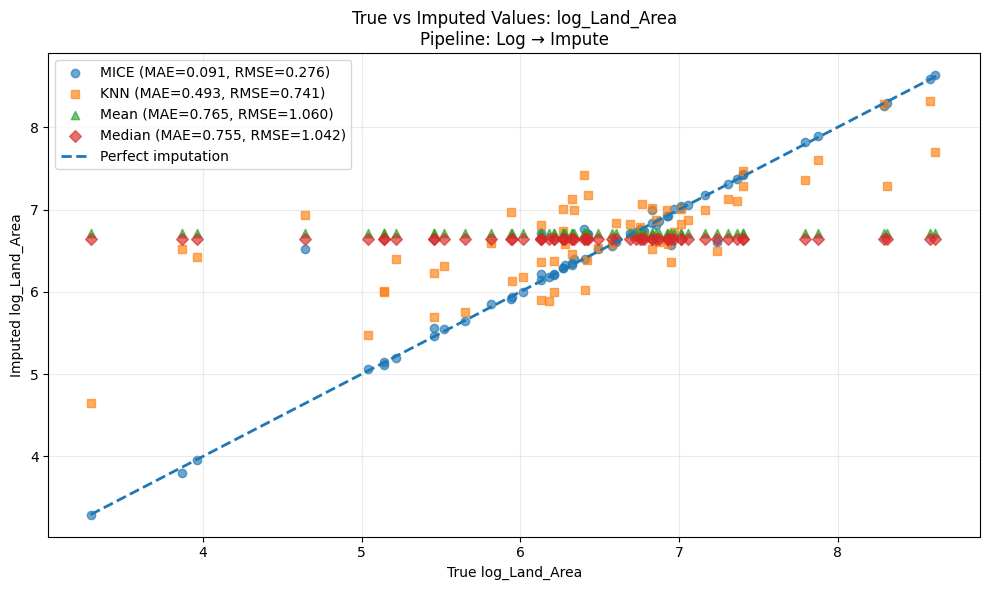

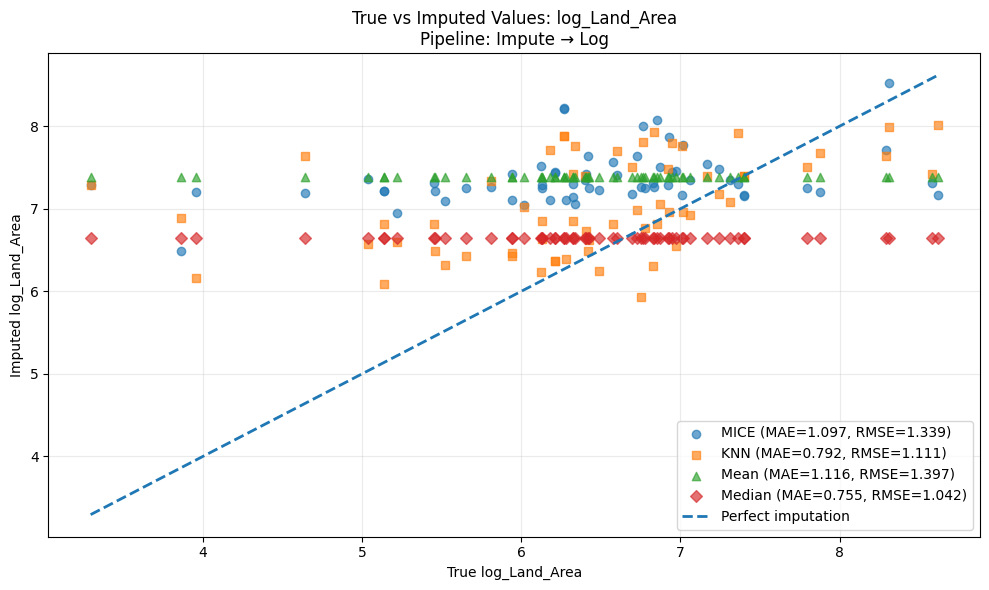

In [ ]:
# =========================
# 12. PLOT ALL LOG VARIABLES
# =========================

log_plot_variables = [
    log_map[col]
    for col in log_vars
]

for variable in log_plot_variables:
    plot_true_vs_imputed(
        variable,
        "Log → Impute"
    )

    plot_true_vs_imputed(
        variable,
        "Impute → Log"
    )

# Feature Filtering


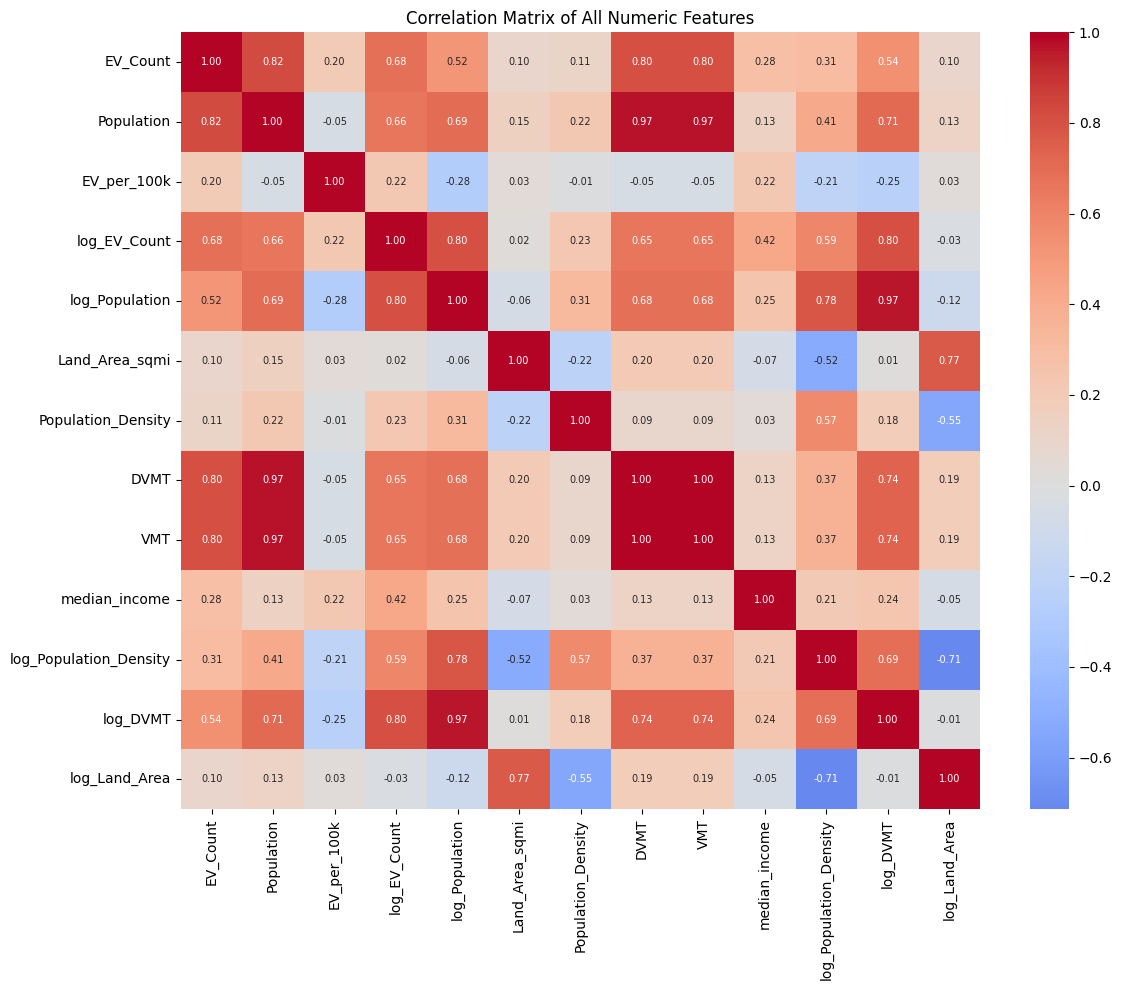


Feature pairs with |correlation| > 0.80:


,Feature1,Feature2,Correlation,Absolute_Correlation
0,DVMT,VMT,1.000000,1.000000
1,Population,VMT,0.970793,0.970793
2,Population,DVMT,0.970793,0.970793
3,log_Population,log_DVMT,0.966006,0.966006
4,EV_Count,Population,0.819832,0.819832
5,log_EV_Count,log_Population,0.803923,0.803923
6,log_EV_Count,log_DVMT,0.802508,0.802508
7,EV_Count,DVMT,0.801035,0.801035
8,EV_Count,VMT,0.801035,0.801035


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# =========================
# 2. SELECT NUMERIC FEATURES
# =========================

numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Variables NOT used for feature filtering
exclude_cols = [

    # Target variables
    "Price_Q25",
    "Price_Q50",
    "log_Price_Q50",
    "Price_Q75",
    "NO2_Q25",
    "NO2_Q50",
    "NO2_Q75",
    "NO2_Mean",
    "NO2_Peak",

    # IDs
    "StateCodeFIPS",
    "fips",
    "EPA_County_Code",
    "EPA_State_Code",
    "MunicipalCodeFIPS",

    # Time
    "Year",

    "EV_New_Stations",

    "EV_Growth_Rate",
    "Price_Growth_Pct"
]

predictor_cols = [
    c for c in corr_cols
    if c not in exclude_cols
]
corr = df[predictor_cols].corr()

# =========================
# 3. CORRELATION MATRIX
# =========================


plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    annot_kws={"size": 7}
)

plt.title("Correlation Matrix of All Numeric Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# =========================
# 4. FIND HIGH CORRELATIONS
# =========================

high_corr = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        correlation = corr.iloc[i, j]

        if abs(correlation) > 0.80:
            high_corr.append({
                "Feature1": corr.columns[i],
                "Feature2": corr.columns[j],
                "Correlation": correlation,
                "Absolute_Correlation": abs(correlation)
            })

high_corr_df = (
    pd.DataFrame(high_corr)
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nFeature pairs with |correlation| > 0.80:")
display(high_corr_df)


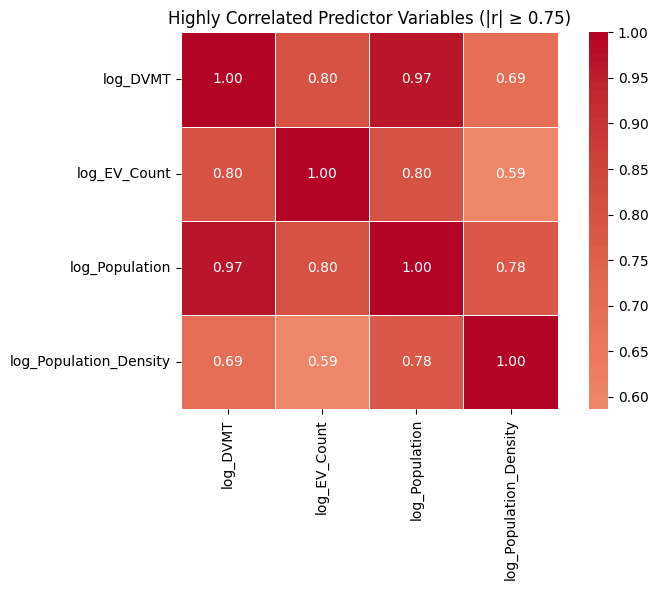

,Feature1,Feature2,Correlation
0,log_Population,log_DVMT,0.966006
1,log_EV_Count,log_Population,0.803923
2,log_EV_Count,log_DVMT,0.802508
3,log_Population,log_Population_Density,0.781699


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================
# Threshold
# ======================================

threshold = 0.75

# Variables NOT used for feature filtering
exclude_cols = [
    # Raw variables replaced by log versions
    "EV_Count",
    "Population",
    "Population_Density",
    "DVMT",
    "Land_Area_sqmi",
    "Price_Q50",

    # Target variables
    "Price_Q25",
    "Price_Q50",
    "log_Price_Q50",
    "Price_Q75",
    "NO2_Q25",
    "NO2_Q50",
    "NO2_Q75",
    "NO2_Mean",
    "NO2_Peak",

    # IDs
    "StateCodeFIPS",
    "fips",
    "EPA_State_Code",
    "MunicipalCodeFIPS",

    # Time
    "Year",

    "EV_New_Stations",

    "EV_Growth_Rate",
    "Price_Growth_Pct"
]

predictor_cols = [
    c for c in corr_cols
    if c not in exclude_cols
]
corr = df[predictor_cols].corr()

# Find variables involved in at least one strong correlation
selected_vars = set()

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= threshold:
            selected_vars.add(corr.columns[i])
            selected_vars.add(corr.columns[j])

selected_vars = sorted(selected_vars)

corr_selected = corr.loc[selected_vars, selected_vars]

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_selected,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(f"Highly Correlated Predictor Variables (|r| ≥ {threshold})")
plt.tight_layout()
plt.show()


corr = df[predictor_cols].corr()

high_corr = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= threshold:
            high_corr.append([
                corr.columns[i],
                corr.columns[j],
                corr.iloc[i, j]
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=["Feature1", "Feature2", "Correlation"]
)

high_corr_df["Abs_Correlation"] = (
    high_corr_df["Correlation"].abs()
)

high_corr_df = (
    high_corr_df
    .sort_values("Abs_Correlation", ascending=False)
    .drop(columns="Abs_Correlation")
    .reset_index(drop=True)
)


display(high_corr_df)

# VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Predictor variables only
predictors = [
    "EV_per_100k",
    "log_EV_Count",
    "log_Population_Density",
    "log_DVMT",
    "median_income"
]

# Remove missing values
X_vif = df[predictors].dropna()

# Add intercept
X_vif = add_constant(X_vif)

# Compute VIF
vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Remove intercept
vif = vif[vif["Feature"] != "const"]

# Sort by VIF
vif = (
    vif
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print(vif)

                  Feature       VIF
0            log_EV_Count  6.256916
1                log_DVMT  6.246255
2             EV_per_100k  2.221536
3  log_Population_Density  1.951983
4           median_income  1.260714
